In [85]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
# Real Data management
import os
import scipy.io

# Imports for math and graphics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy
from kneed import KneeLocator

# Our package
import neuro_lib as nlib
from neuro_lib.plotting import TE_heatMat
from neuro_lib.transfer_entropy import transfer_entropy_matrix

# MUTUAL INFORMATION ESTIMATION ON REAL BRAIN DATA TIME SERIES

## Data description

The data are brain signals recorded via resting-state functional MRI (fMRI).  
Each of the two matrices contains **1200 time points** for **119 brain regions**.  
The two matrices correspond to two recording sessions of the same subject  
(ideally, they could be used to verify the consistency of the estimates).

## Tasks

1. If computationally feasible, calculate a **transfer entropy matrix** of size 119 × 119,  
   where the element (i,j) represents the **transfer entropy** from the i-th signal to the j-th signal.
2. Compare the matrices obtained using different methods.
3. Evaluate the **consistency** of the results across the two sessions.

**Note:** If the computation is too heavy, you can restrict yourself to a **subset of the time series**  
(for example, the first 10 regions or even just the first 2).

# Load the data

In [87]:
# Define the data directory
data_dir = "Data"

# Define the file names
file1 = "100307.REST1.LR.SchaeferS.ptseries.mat"
file2 = "100307.REST2.LR.SchaeferS.ptseries.mat"

# Construct full paths
path1 = os.path.join(data_dir, file1)
path2 = os.path.join(data_dir, file2)

# Load the .mat files
data1 = scipy.io.loadmat(path1)
data2 = scipy.io.loadmat(path2)

# Check the keys in the loaded data
print("Keys in REST1 data:", data1.keys())
print("Keys in REST2 data:", data2.keys())

# Get time series
data1_mat = data1['tseries']  # shape (119, 1200)
data2_mat = data2['tseries']  # shape (119, 1200)

Keys in REST1 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])
Keys in REST2 data: dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


# **TE METHODS IMPLEMENTATIONS**

Transfer Entropy from a source signal $S$ to a target signal $X$ is defined as:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

where $\ell$ is the chosen lag.

# Binning

The binning approach estimates entropies by discretizing continuous variables:

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Discretization:**
   Each variable is divided into $n_{\text{bins}}$ intervals, and empirical counts are computed.

3. **Conditional entropy estimation:**
   - $H(X_t \mid X_{t-1})$ is computed using a 2D histogram
   - $H(X_t \mid X_{t-1}, S_{t-\ell})$ is computed using a 3D histogram

4. **Transfer Entropy:**
$$
TE = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

#### Notes

- A Miller bias correction can optionally be applied.
- The method is fully non-parametric.
- It can capture nonlinear dependencies, but is sensitive to:
  - number of bins
  - finite sample effects (especially in higher dimensions)

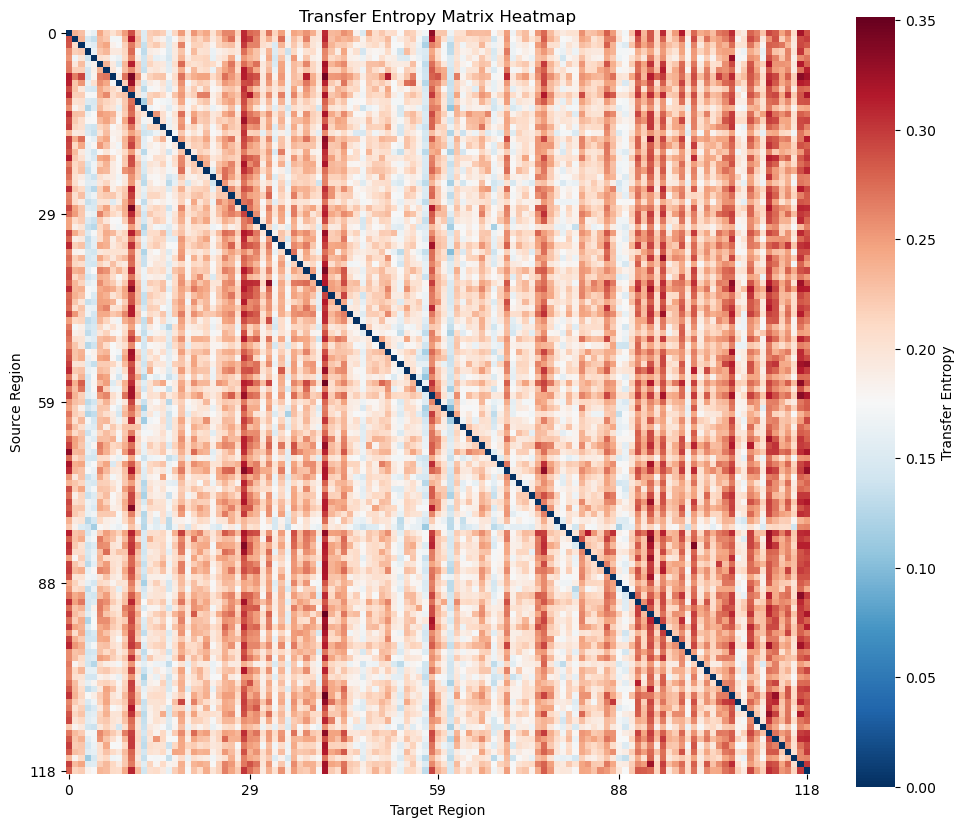

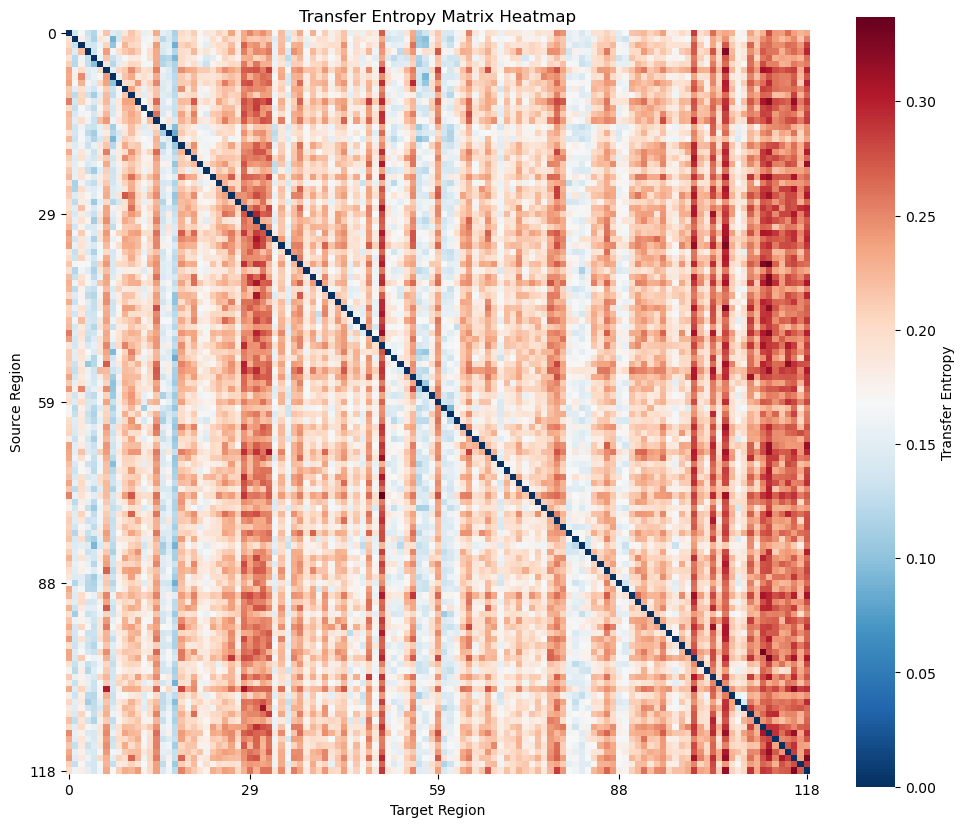

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [88]:
nbins = int(1200**(1/3))
TE_real_bin_1 = nlib.transfer_entropy_matrix(data1_mat, n_bins=nbins, lag=1)
TE_real_bin_2 = nlib.transfer_entropy_matrix(data2_mat, n_bins=nbins, lag=1)
TE_heatMat(TE_real_bin_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_bin_2, cmap="RdBu_r", figsize=(12,10))

# Joint Gaussian assumption

Under the assumption that variables are jointly Gaussian, Transfer Entropy can be computed analytically.

Starting from:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

For Gaussian variables, conditional entropy depends only on conditional variance:
$$
H(X \mid Y) = \frac{1}{2} \log(2\pi e \, \mathrm{Var}(X \mid Y))
$$

Thus, Transfer Entropy becomes:
$$
TE = \frac{1}{2} \log \left( \frac{\mathrm{Var}(X_t \mid X_{t-1})}{\mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})} \right)
$$

So the implementation proceeds as follows: 

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Conditional variances are computed using covariance matrices:**
$$
\mathrm{Var}(X \mid Y) =
\mathrm{Var}(X) - \mathrm{Cov}(X,Y)\,\mathrm{Var}(Y)^{-1}\,\mathrm{Cov}(Y,X)
$$

3. **Transfer Entropy is obtained as:**
$$
TE = \frac{1}{2} \log \left( \frac{\mathrm{Var}_1}{\mathrm{Var}_2} \right)
$$

where:
- $\mathrm{Var}_1 = \mathrm{Var}(X_t \mid X_{t-1})$
- $\mathrm{Var}_2 = \mathrm{Var}(X_t \mid X_{t-1}, S_{t-\ell})$

#### Notes

- Equivalent to linear Granger causality under Gaussian assumptions.
- Computationally efficient and robust for high-dimensional data.
- Only captures **linear dependencies**.


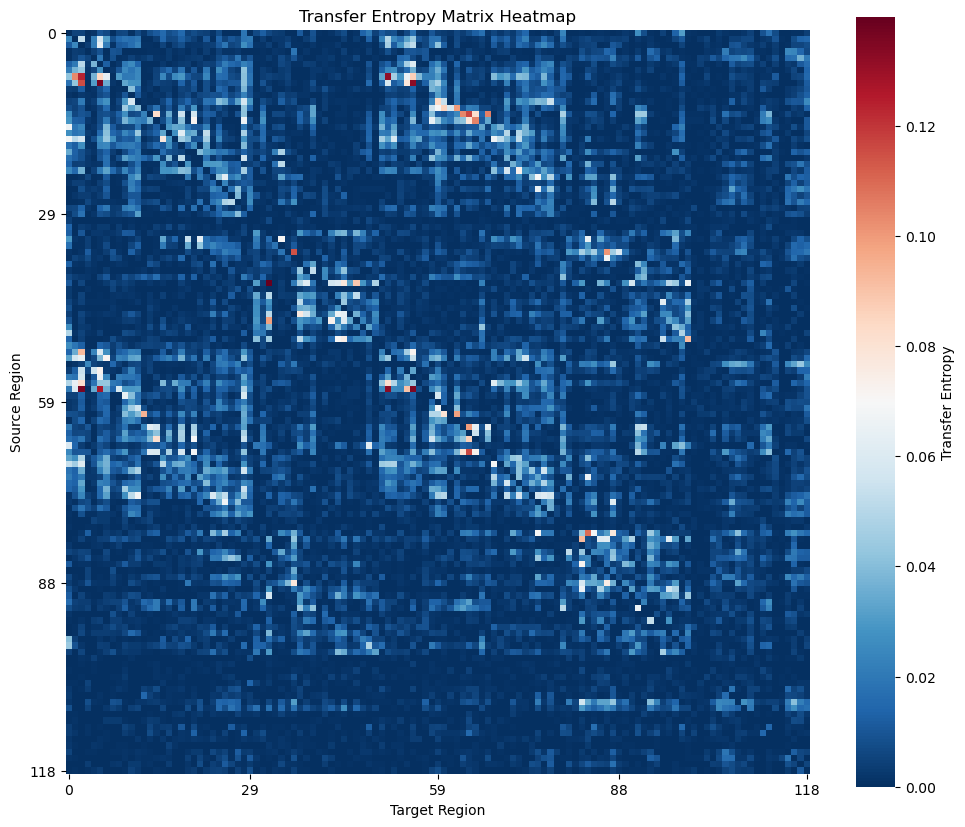

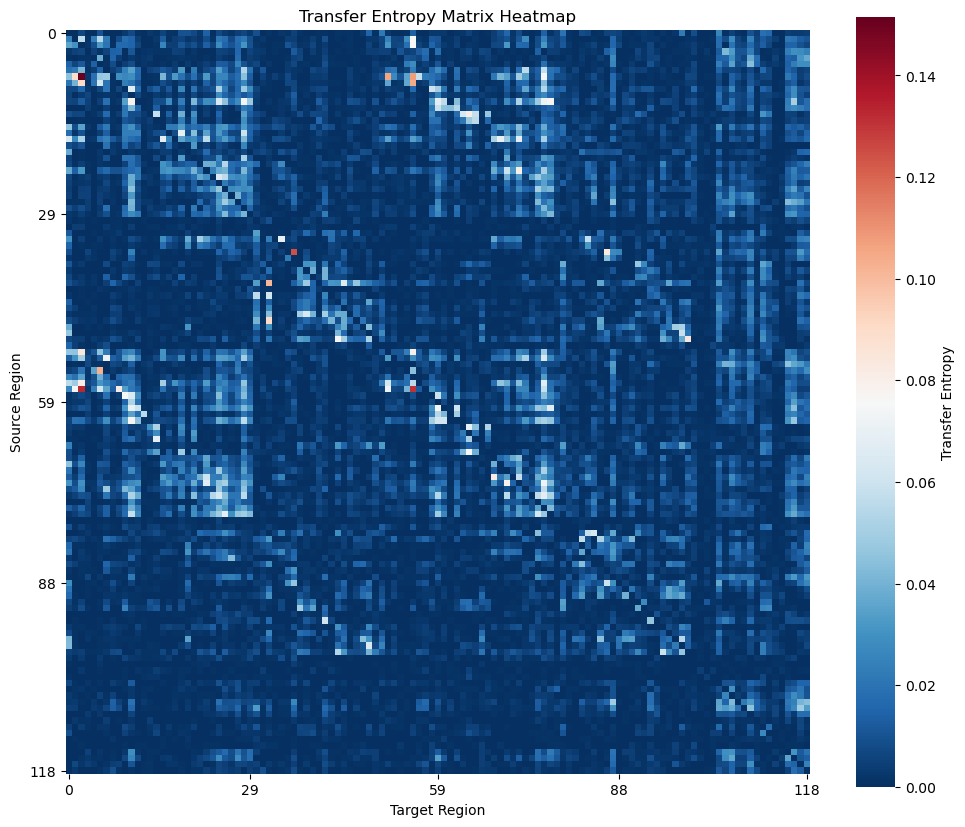

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [89]:
TE_real_gauss_1 = nlib.transfer_entropy_matrix(data1_mat, method = "gaussian", lag=1)
TE_real_gauss_2 = nlib.transfer_entropy_matrix(data2_mat, method = "gaussian", lag=1)
TE_heatMat(TE_real_gauss_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_gauss_2, cmap="RdBu_r",  figsize=(12,10))

# KDE method

Transfer Entropy can be expressed in terms of conditional entropy:
$$
TE_{S \to X} = H(X_t \mid X_{t-1}) - H(X_t \mid X_{t-1}, S_{t-\ell})
$$

This is the **direct entropy decomposition**, equivalent to the conditional MI formulation
$I(X_t ; S_{t-\ell} \mid X_{t-1})$, but more natural for KDE-based estimation.

Using the chain rule of entropy, each conditional entropy expands as:
$$
H(X_t \mid X_{t-1}) = H(X_t, X_{t-1}) - H(X_{t-1})
$$
$$
H(X_t \mid X_{t-1}, S_{t-\ell}) = H(X_t, X_{t-1}, S_{t-\ell}) - H(X_{t-1}, S_{t-\ell})
$$

so the full expression becomes:
$$
TE = \underbrace{H(X_t, X_{t-1}, S_{t-\ell})}_{\text{3D}} 
   - \underbrace{H(X_{t-1}, S_{t-\ell})}_{\text{2D}} 
   - \underbrace{H(X_t, X_{t-1})}_{\text{2D}} 
   + \underbrace{H(X_{t-1})}_{\text{1D}}
$$

which in plug-in KDE form is:
$$
TE = -\mathbb{E}\bigl[\log_2 p(X_t, X_{t-1}, S_{t-\ell})\bigr]
   + \mathbb{E}\bigl[\log_2 p(X_{t-1}, S_{t-\ell})\bigr]
   + \mathbb{E}\bigl[\log_2 p(X_t, X_{t-1})\bigr]
   - \mathbb{E}\bigl[\log_2 p(X_{t-1})\bigr]
$$

#### Implementation

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (lagged source)
   - $X_{t-1}$ (past of target)
   - $X_t$ (current target)

2. **Four KDE density estimates are computed** (plug-in: KDE fitted and evaluated on the same samples):
   - $p(X_t, X_{t-1}, S_{t-\ell})$ — 3D joint
   - $p(X_{t-1}, S_{t-\ell})$ — 2D joint
   - $p(X_t, X_{t-1})$ — 2D joint
   - $p(X_{t-1})$ — 1D marginal

3. **Transfer Entropy** is computed as the sample average:
$$
TE = \mathbb{E}\bigl[\log_2 p(X_t, X_{t-1}, S_{t-\ell}) - \log_2 p(X_{t-1}, S_{t-\ell})
   - \log_2 p(X_t, X_{t-1}) + \log_2 p(X_{t-1})\bigr]
$$

#### Notes

- Fully non-parametric: captures nonlinear dependencies without distributional assumptions.
- More flexible than Gaussian TE, but:
  - computationally expensive
  - sensitive to bandwidth selection (parameter $\alpha$)
  - the 3D KDE fit degrades with fewer than ~500 samples

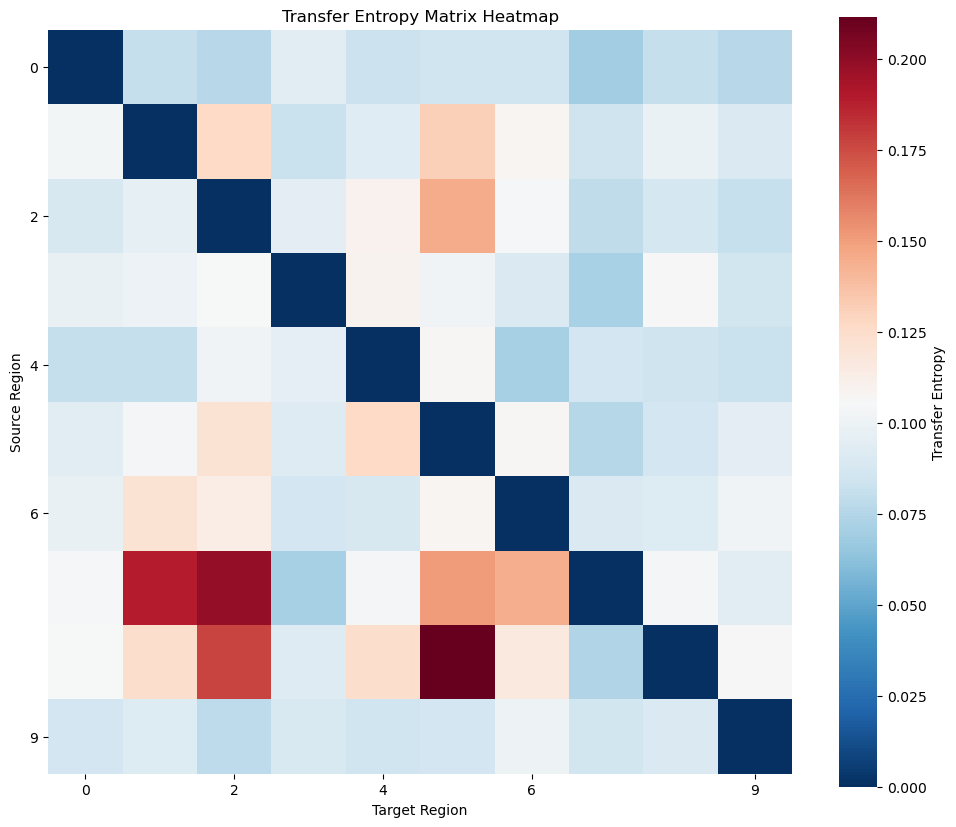

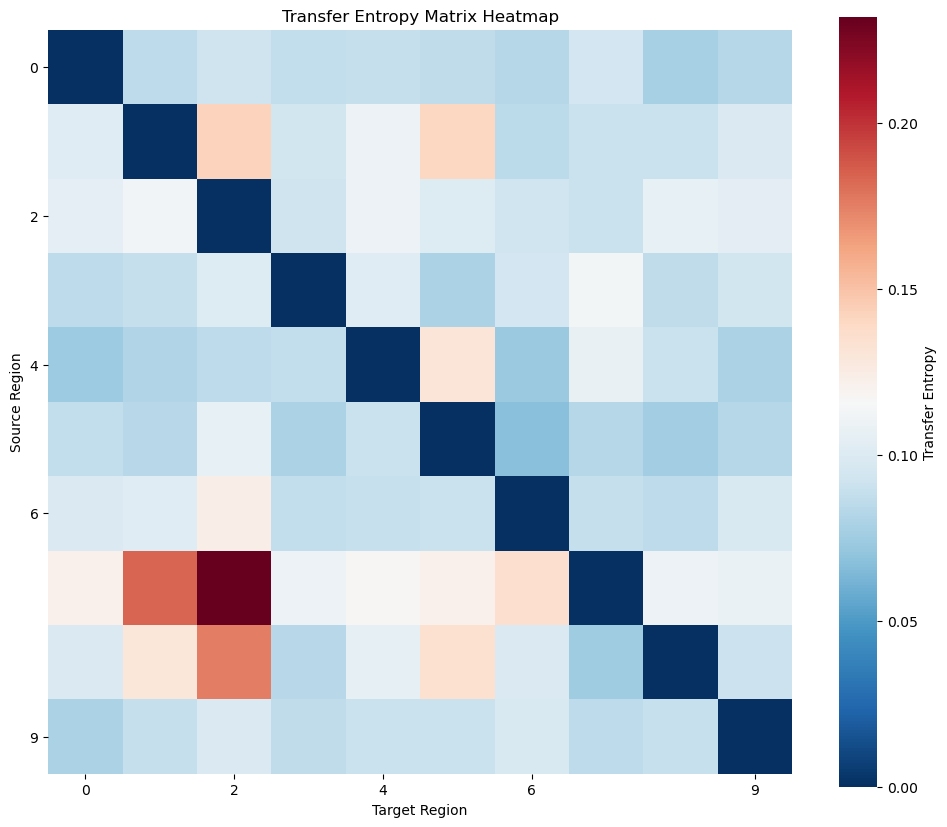

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [90]:
# NOTICE: on full data is VERY SLOW - KDE scales very badly with both sample 
#         size and dimensionality --> we reduce analysis to first 10 brain regions
TE_real_kde_1 = nlib.transfer_entropy_matrix(data1_mat[:10,:], method="kde", alpha=1.0)
TE_real_kde_2 = nlib.transfer_entropy_matrix(data2_mat[:10,:], method="kde", alpha=1.0)

TE_heatMat(TE_real_kde_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_kde_2, cmap="RdBu_r", figsize=(12,10))

# Gaussian Copula Method

The Gaussian Copula approach provides a semi-parametric method to estimate Transfer Entropy by combining:
- non-parametric marginal distributions
- Gaussian dependence modeling in a transformed space

The starting point is:
$$
TE_{S \to X} = I(X_t ; S_{t-\ell} \mid X_{t-1})
$$

Using the identity:
$$
TE = I(X_t ; S_{t-\ell}, X_{t-1}) - I(X_t ; X_{t-1})
$$

#### Implementation

1. **Lagged variables are constructed:**
   - $S_{t-\ell}$ (source)
   - $X_{t-1}$ (target past)
   - $X_t$ (target)

2. **Gaussian Copula transformation:**
   - Each variable is mapped to its empirical CDF:
     $U_X = F_X(X)$
   - Then transformed to Gaussian space:
     $Z_X = \Phi^{-1}(U_X)$

   This step preserves rank structure while enforcing Gaussian marginals.

3. **Gaussian MI in transformed space:**
   - $I(X_t ; X_{t-1})$
   - $I(X_t ; X_{t-1}, S_{t-\ell})$

   are computed assuming multivariate Gaussian structure via covariance matrices.

4. **Transfer Entropy:**
$$
TE = I(X_t ; S_{t-\ell}, X_{t-1}) - I(X_t ; X_{t-1})
$$

#### Notes

- This method is **nonlinear in marginals but Gaussian in dependence structure**.
- It is more flexible than standard Gaussian TE, since:
  - marginal distributions are fully non-parametric
- Compared to KDE:
  - more stable in moderate sample sizes
  - less flexible in capturing arbitrary nonlinear dependencies
- Compared to binning:
  - avoids discretization artifacts
  - but assumes Gaussian copula structure after transformation
- Requires multivariate Gaussian MI (via covariance determinants): for jointly Gaussian variables the mutual information between a scalar variable $X$ and a vector $Y \in \mathbb{R}^d$ is given by:
$$
I(X;Y) = \frac{1}{2}\log_2 \left( \frac{\det \Sigma_X \, \det \Sigma_Y}{\det \Sigma_{XY}} \right)
$$

where:
- $\Sigma_X \in \mathbb{R}^{1 \times 1}$ is the variance of $X$,
- $\Sigma_Y \in \mathbb{R}^{d \times d}$ is the covariance matrix of $Y = (X_{t-1}, S_{t-\ell})$,
- $\Sigma_{XY} \in \mathbb{R}^{(d+1)\times(d+1)}$ is the full joint covariance matrix of $(X, Y)$.

This replaces the previous pairwise-only formula:
$$
I(X;Y) = -\frac{1}{2}\log_2(1 - \rho^2)
$$
which is valid only in the special case where both $X$ and $Y$ are scalar random variables.

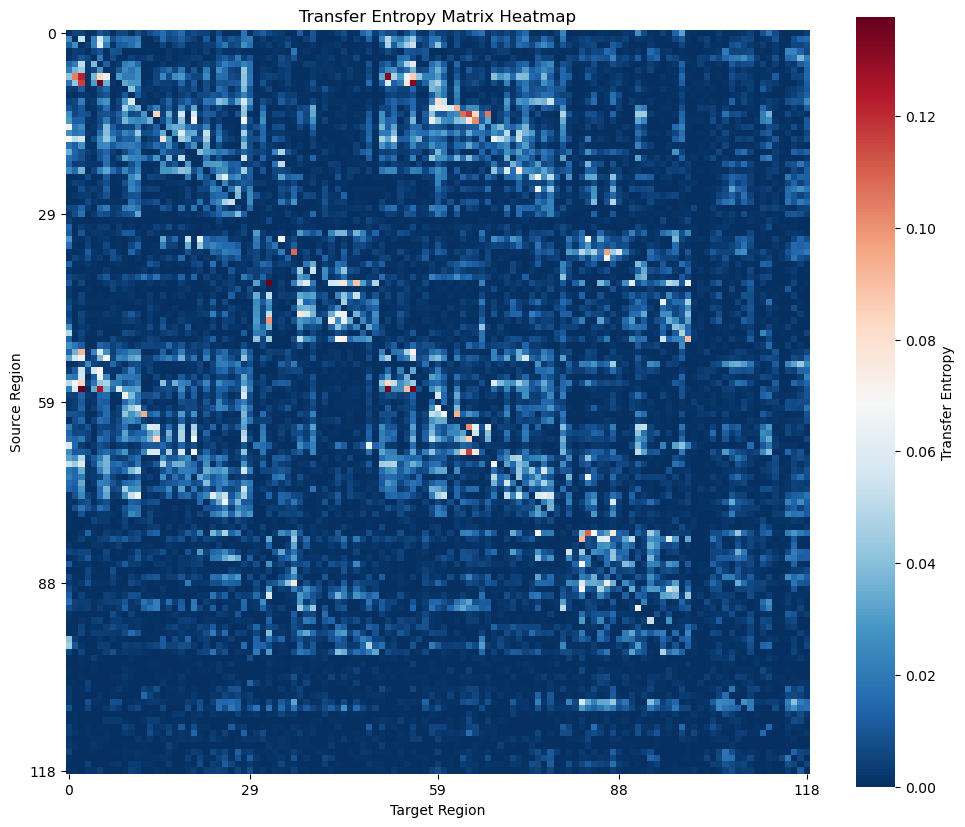

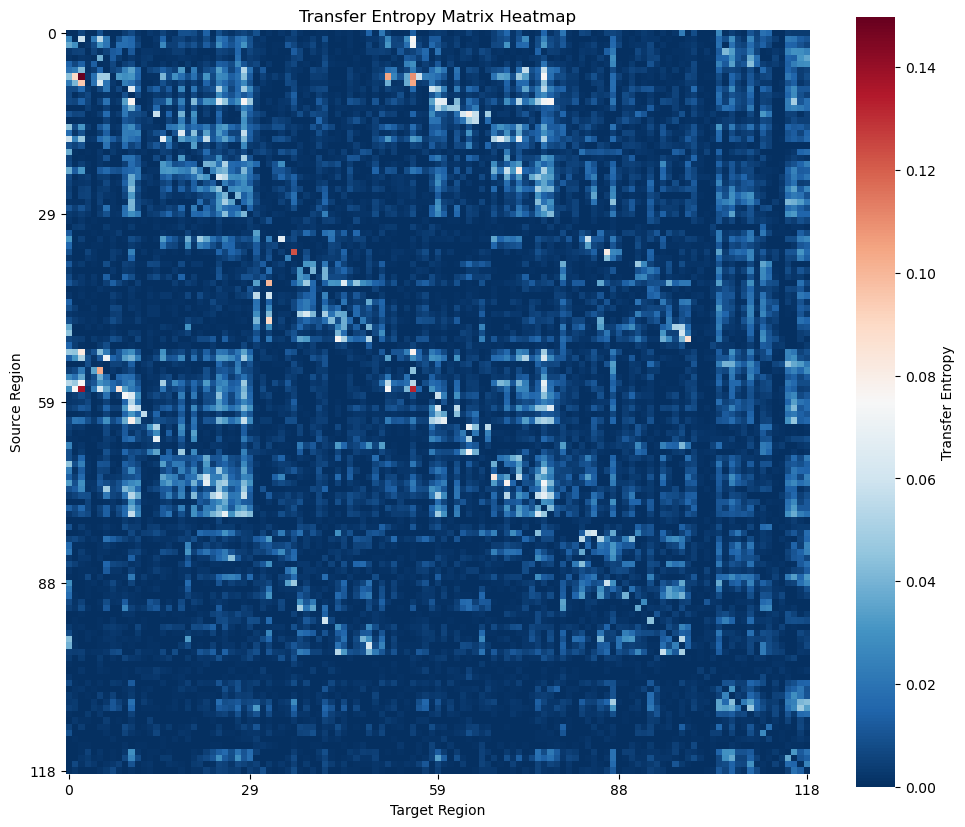

<Axes: title={'center': 'Transfer Entropy Matrix Heatmap'}, xlabel='Target Region', ylabel='Source Region'>

In [91]:
TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat, method="copula")
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat, method="copula")

TE_heatMat(TE_real_copula_1, cmap="RdBu_r", figsize=(12,10))
TE_heatMat(TE_real_copula_2, cmap="RdBu_r", figsize=(12,10))

# **ANALYSIS** - **NULL HYPOTHESIS**

We eant to distinguish real TE from the apparent one coming from finite-sample bias. 

We can thus compare the above results with a null hypothesis obtained by shuffling the data so to destroy correlations. 

We start from considering **dataset 1**. 

In [92]:
# PARAMETERS FOR CONSISTENCY BETWEEN REAL AND NULL ARE SET HERE!
lag = 4
kde_regions = 10

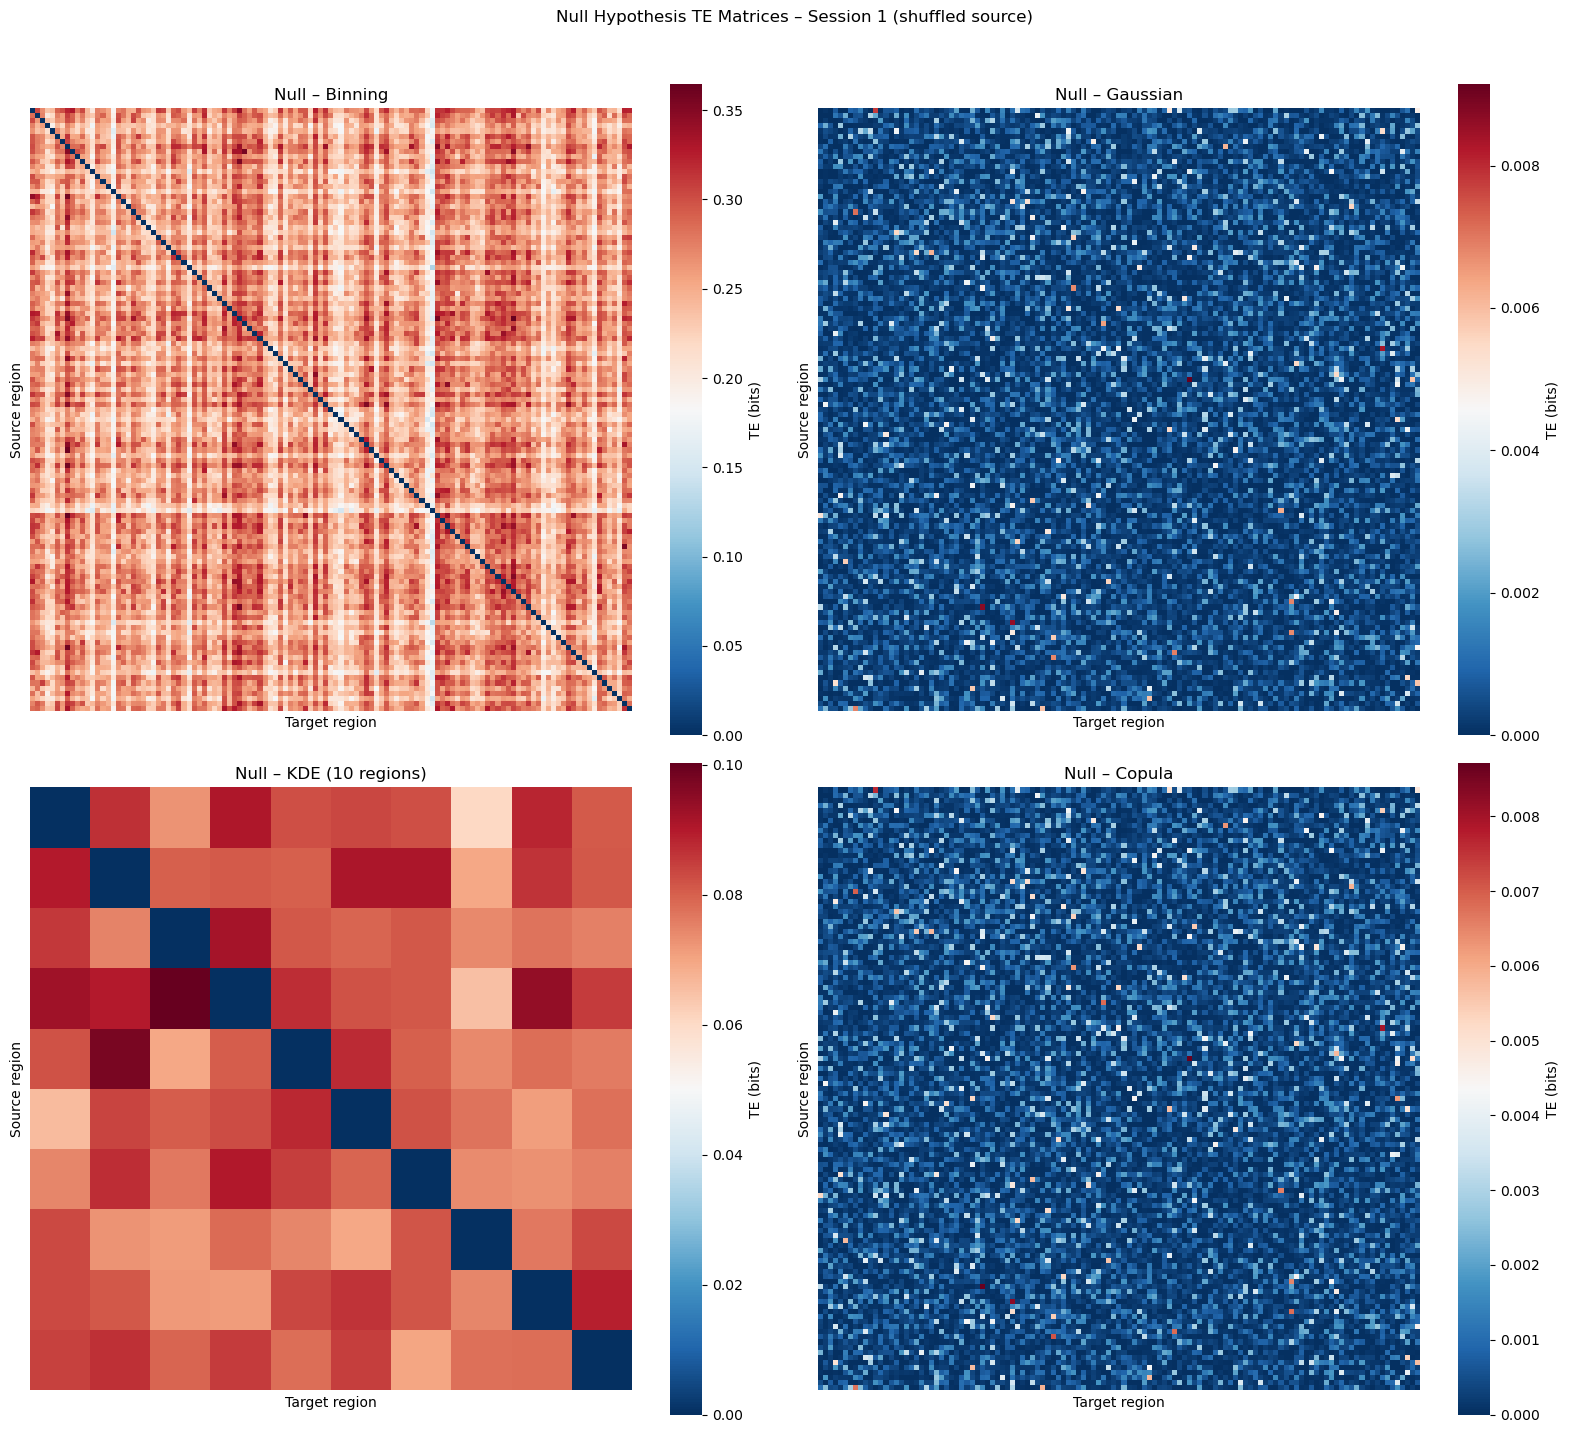

In [93]:
# Shuffle sources (preserves marginals, destroys temporal structure) ──────
data1_shuffled = np.array([np.random.permutation(data1_mat[i])
                           for i in range(data1_mat.shape[0])])

# Null matrices (one per method × session)
TE_null_gauss  = nlib.transfer_entropy_matrix(data1_shuffled,        method="gaussian", lag=lag)
TE_null_bin    = nlib.transfer_entropy_matrix(data1_shuffled,        method="binning",  lag=lag, n_bins=nbins)
TE_null_copula = nlib.transfer_entropy_matrix(data1_shuffled,        method="copula",   lag=lag)
TE_null_kde    = nlib.transfer_entropy_matrix(data1_shuffled[:kde_regions,:], method="kde",      lag=lag)

# Plot all four nulls side by side 
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

null_matrices = [TE_null_bin, TE_null_gauss, TE_null_kde, TE_null_copula]
null_titles   = ["Null – Binning", "Null – Gaussian", "Null – KDE (10 regions)", "Null – Copula"]

for ax, mat, title in zip(axes.flat, null_matrices, null_titles):
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        square=True,
        cbar_kws={"label": "TE (bits)"},
        xticklabels=False,
        yticklabels=False
    )
    ax.set_title(title)
    ax.set_xlabel("Target region")
    ax.set_ylabel("Source region")

plt.suptitle("Null Hypothesis TE Matrices – Session 1 (shuffled source)", y=1.02)
plt.tight_layout()
plt.show()

Ideally, with infinite data, the null matrices would be entirely zero. If you shuffle the source, you break all temporal coupling, so TE should be exactly zero for every pair. The shuffled source $X^{shuffled}$ is by construction independent of $Y_t$ and $Y_{t-1}$, so knowing it adds no information about Y's future. 

What we'll see is actually _small but non-zero values uniformly spread_ across the matrix, with no particular structure. This is "finite-sample bias". This bias differs across methods. 

**Gaussian and Gaussian copula**: shows the lowest and most uniform null values. Copula indeed does the same estimation of Gauss after a rank transformation that being deterministic does not introduce additional randomness. The fact that it stays low is that we estimate a single joint covariance matrix from the 1200 triplets (the rest obtained analytically from submatrices $\Sigma$. 

$$
\Sigma = \begin{pmatrix} 
\text{Var}(Y_t) & \text{Cov}(Y_t, Y_{t-1}) & \text{Cov}(Y_t, X_{t-\ell}) \\ 
\text{Cov}(Y_{t-1}, Y_t) & \text{Var}(Y_{t-1}) & \text{Cov}(Y_{t-1}, X_{t-\ell}) \\ 
\text{Cov}(X_{t-\ell}, Y_t) & \text{Cov}(X_{t-\ell}, Y_{t-1}) & \text{Var}(X_{t-\ell}) 
\end{pmatrix}
$$. 

**Binning**: shows noticeably higher values due to the fact that we have we have many cells nearly empty, and sparse counts inflate entropy estimate systematically. (p small, logp is large and negative, -plogp is positive). This is the _Miller-Madow bias_: sparse histograms systematically overestimate entropy, and the effect is large when cells are nearly empty.  Furthermore, we see vertical/horizontal stripes.  The stripe pattern means certain rows or columns are systematically brighter — meaning a specific region i consistently produces high TE as a source regardless of which target j you pair it with, and vice versa for columns. This happens because the bias is not uniform across regions - it depends on the marginal distribution of each signal. If region i has a distribution with very low variance or heavily skewed, this inflation is tied to the region's own distribution rather than its interaction with any specific partner, it appears as a stripe. In other words: when you bin region i's time series to build the histogram axis for source $X_{t-l}$, the resulting 3D histogram is sparse in a way that is specific to region i — and that sparsity inflates the TE estimate for
every pair involving region i as source, regardless of what the target region is. (Simply: _the fact that X has no counts in some bins lowers the overall number of counts in cells characterized by that X_). Since we're reshuffling each signal alone, and the reshuffling does not change the internal distribution, this structure is kept (what is destroyed is temporal structure). 

**KDE**: intermediate bias - larger than Gaussian because four separate nonparametric fits accumulate more estimation error than a single covariance matrix, but smaller than binning because there are no empty cells causing catastrophic inflation. KDE indeed fits four _independent_ nonparametric density objects from the data:

- $\hat{p}(Y_t, Y_{t-1}, X_{t-\ell})$ — 3D joint density
- $\hat{p}(Y_{t-1}, X_{t-\ell})$ — 2D joint density
- $\hat{p}(Y_t, Y_{t-1})$ — 2D joint density
- $\hat{p}(Y_{t-1})$ — 1D marginal density

Each is fitted independently from the raw data, with its own bandwidth and its own 
estimation error. They are not derived from one another.

# **REAL VS NULL**

In [94]:
TE_real_bin_1    = nlib.transfer_entropy_matrix(data1_mat,        method="binning",  lag=lag, n_bins=nbins)
TE_real_gauss_1  = nlib.transfer_entropy_matrix(data1_mat,        method="gaussian", lag=lag)
TE_real_kde_1    = nlib.transfer_entropy_matrix(data1_mat[:kde_regions,:], method="kde",      lag=lag)
TE_real_copula_1 = nlib.transfer_entropy_matrix(data1_mat,        method="copula",   lag=lag)

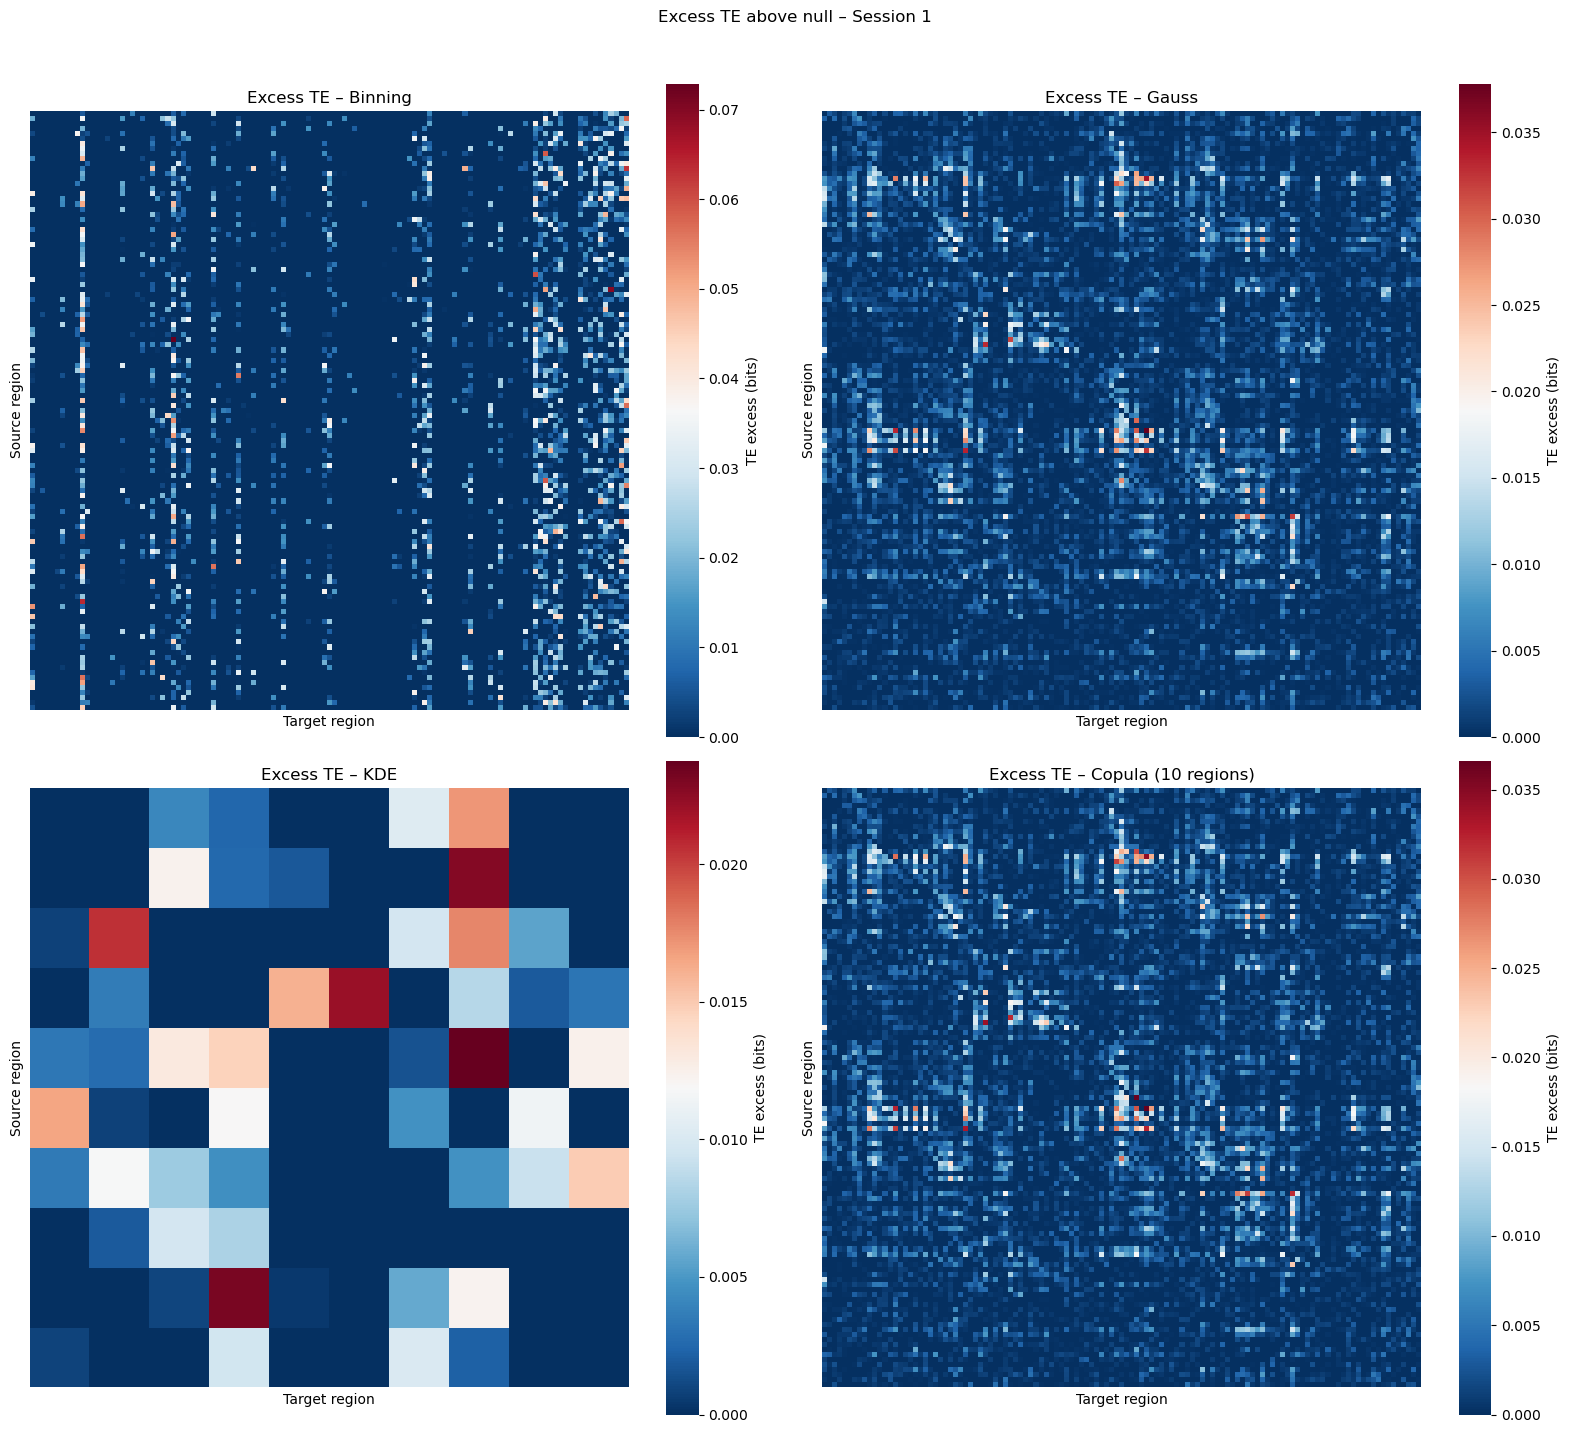

In [95]:
# Compute excess TE (real minus null, clipped at zero)
# We clip because if the estimator is finding less structure in real data than 
# in null model, the null would be over-estimated for that paur just by chance.
TE_excess_bin_1    = np.maximum(TE_real_bin_1    - TE_null_bin,    0)
TE_excess_gauss_1  = np.maximum(TE_real_gauss_1  - TE_null_gauss,  0)
TE_excess_kde_1    = np.maximum(TE_real_kde_1    - TE_null_kde,    0)
TE_excess_copula_1 = np.maximum(TE_real_copula_1 - TE_null_copula, 0)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

excess_matrices_1 = [TE_excess_bin_1, TE_excess_gauss_1, TE_excess_kde_1, TE_excess_copula_1]
excess_titles   = ["Excess TE – Binning", "Excess TE – Gauss", 
                   "Excess TE – KDE",   "Excess TE – Copula (10 regions)"]

for ax, mat, title in zip(axes.flat, excess_matrices_1, excess_titles):
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        square=True,
        cbar_kws={"label": "TE excess (bits)"},
        xticklabels=False,
        yticklabels=False
    )
    ax.set_title(title)
    ax.set_xlabel("Target region")
    ax.set_ylabel("Source region")

plt.suptitle("Excess TE above null – Session 1", y=1.02)
plt.tight_layout()
plt.show()

Let's check the **dataset 2**. 

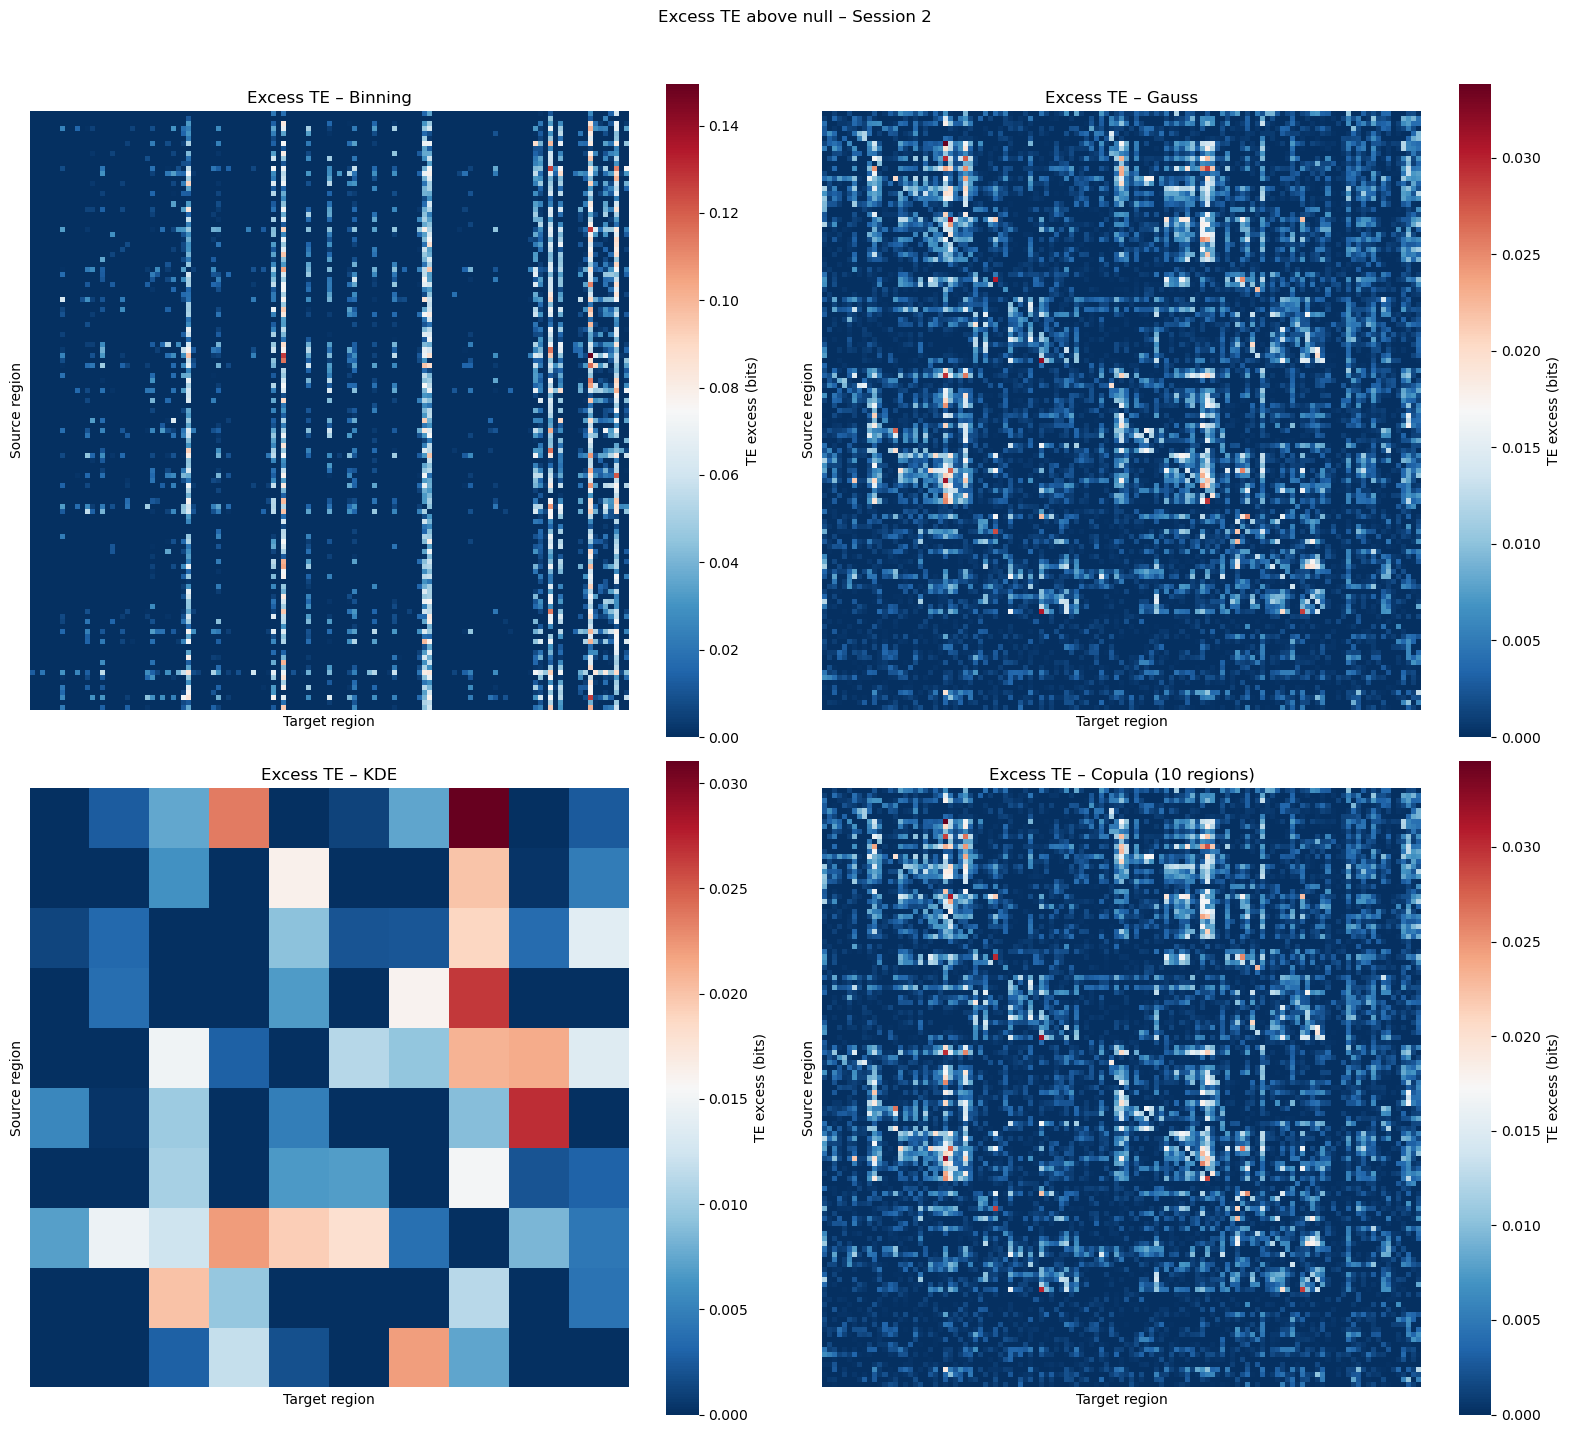

In [96]:
TE_real_bin_2    = nlib.transfer_entropy_matrix(data2_mat,        method="binning",  lag=lag, n_bins=nbins)
TE_real_gauss_2  = nlib.transfer_entropy_matrix(data2_mat,        method="gaussian", lag=lag)
TE_real_kde_2    = nlib.transfer_entropy_matrix(data2_mat[:kde_regions,:], method="kde",      lag=lag)
TE_real_copula_2 = nlib.transfer_entropy_matrix(data2_mat,        method="copula",   lag=lag)

# Compute excess TE (real minus null, clipped at zero)
TE_excess_bin_2    = np.maximum(TE_real_bin_2    - TE_null_bin,    0)
TE_excess_gauss_2  = np.maximum(TE_real_gauss_2  - TE_null_gauss,  0)
TE_excess_kde_2    = np.maximum(TE_real_kde_2    - TE_null_kde,    0)
TE_excess_copula_2 = np.maximum(TE_real_copula_2 - TE_null_copula, 0)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

excess_matrices_2 = [TE_excess_bin_2, TE_excess_gauss_2, TE_excess_kde_2, TE_excess_copula_2]
excess_titles   = ["Excess TE – Binning", "Excess TE – Gauss", 
                   "Excess TE – KDE",   "Excess TE – Copula (10 regions)"]

for ax, mat, title in zip(axes.flat, excess_matrices_2, excess_titles):
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        square=True,
        cbar_kws={"label": "TE excess (bits)"},
        xticklabels=False,
        yticklabels=False
    )
    ax.set_title(title)
    ax.set_xlabel("Target region")
    ax.set_ylabel("Source region")

plt.suptitle("Excess TE above null – Session 2", y=1.02)
plt.tight_layout()
plt.show()

We can also compare the **consistency across the two datasets** in the same way 

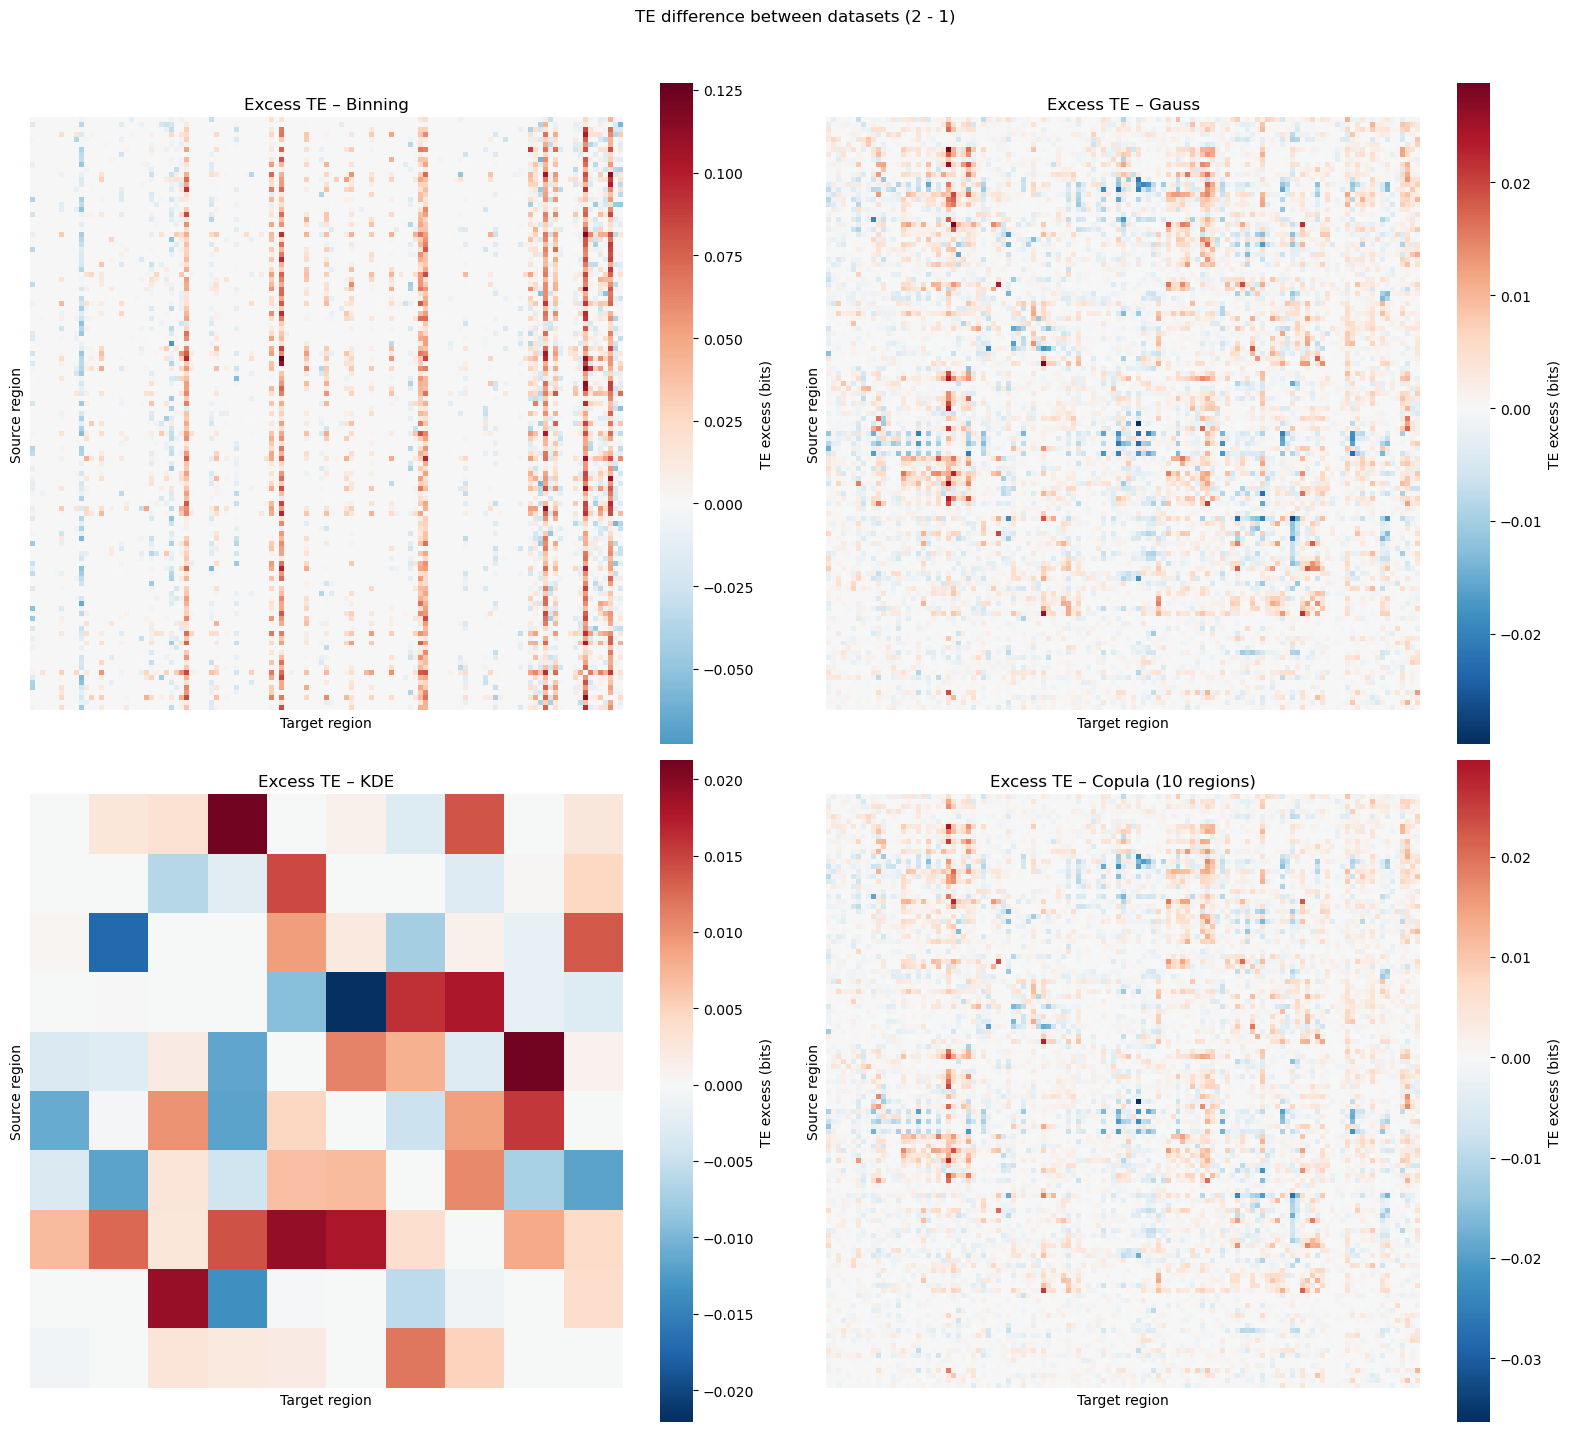

In [97]:
TE_excess_12_bin    = TE_excess_bin_2 - TE_excess_bin_1
TE_excess_12_gauss  = TE_excess_gauss_2  - TE_excess_gauss_1
TE_excess_12_kde  = TE_excess_kde_2    - TE_excess_kde_1
TE_excess_12_copula = TE_excess_copula_2 - TE_excess_copula_1

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

excess_btw_datasets = [TE_excess_12_bin, TE_excess_12_gauss, TE_excess_12_kde, TE_excess_12_copula]
excess_titles   = ["Excess TE – Binning", "Excess TE – Gauss", 
                   "Excess TE – KDE",   "Excess TE – Copula (10 regions)"]

for ax, mat, title in zip(axes.flat, excess_btw_datasets, excess_titles):
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        center = 0, 
        square=True,
        cbar_kws={"label": "TE excess (bits)"},
        xticklabels=False,
        yticklabels=False
    )
    ax.set_title(title)
    ax.set_xlabel("Target region")
    ax.set_ylabel("Source region")

plt.suptitle("TE difference between datasets (2 - 1)", y=1.02)
plt.tight_layout()
plt.show()

Overall, 

**Binning:** we observe that stripe structure persists even after null subtraction, confirming that the structured bias tied to individual regions' marginal distributions is not removed by subtracting a single null. Notably the stripes are present in both sessions around the same column positions, meaning the same regions have unusual marginal distributions in both recordings, which is a property of those brain regions, not of the session. The values are also larger and more concentrated around some columns in session 2, suggesting session-to-session variability in the binning estimator is high. 

**KDE:** consistent between datasets, of hard interpretability. We can observe some positive Excess TE, as we sparsely observe here and there in any of the methods. 

**Gaussian:** both sessions show a clear block of elevated connectivity in the upper-left corner of the matrix. This block is visible in both sessions, at similar magnitude, which is already a strong consistency signal. 

**Gaussian Copula:** agreement between Gaussian and Copula across both sessions is the strongest result in the entire analysis. It tells you two things simultaneously: first, the connectivity structure is real and not an artifact of distributional assumptions; second, the linear Gaussian approximation is sufficient to capture the dominant structure, since Copula's additional flexibility in handling non-Gaussian marginals does not change the picture meaningfully.

Now we want to check for the results that are robust across methods and datasets. 
We keep only pairs that have positive excess TE in both Gauss and Copula. 

In [98]:
# Boolean masks: True where excess TE is positive (above null)
mask_gauss_1  = TE_excess_gauss_1  > 0
mask_gauss_2  = TE_excess_gauss_2  > 0
mask_copula_1 = TE_excess_copula_1 > 0
mask_copula_2 = TE_excess_copula_2 > 0

# Robust connections: positive in ALL four combinations
robust_mask = mask_gauss_1 & mask_gauss_2 & mask_copula_1 & mask_copula_2

# Remove diagonal (self-connections are always zero)
np.fill_diagonal(robust_mask, False)

# Extract pairs and their values
rows, cols = np.where(robust_mask)

print(f"Number of robust connections: {len(rows)}")
print()
print(f"{'Source':>8} {'Target':>8} | {'Gauss S1':>10} {'Gauss S2':>10} | {'Copula S1':>10} {'Copula S2':>10}")
print("-" * 65)
for i, j in zip(rows, cols):
    print(f"{i:>8} {j:>8} | "
          f"{TE_excess_gauss_1[i,j]:>10.4f} {TE_excess_gauss_2[i,j]:>10.4f} | "
          f"{TE_excess_copula_1[i,j]:>10.4f} {TE_excess_copula_2[i,j]:>10.4f}")

Number of robust connections: 6897

  Source   Target |   Gauss S1   Gauss S2 |  Copula S1  Copula S2
-----------------------------------------------------------------
       0        1 |     0.0030     0.0001 |     0.0027     0.0000
       0        2 |     0.0016     0.0010 |     0.0017     0.0011
       0        4 |     0.0011     0.0001 |     0.0012     0.0001
       0        5 |     0.0018     0.0017 |     0.0018     0.0015
       0        9 |     0.0012     0.0002 |     0.0012     0.0001
       0       10 |     0.0031     0.0023 |     0.0032     0.0023
       0       12 |     0.0019     0.0006 |     0.0030     0.0005
       0       14 |     0.0036     0.0015 |     0.0037     0.0012
       0       15 |     0.0037     0.0066 |     0.0041     0.0078
       0       16 |     0.0016     0.0049 |     0.0016     0.0053
       0       17 |     0.0007     0.0046 |     0.0009     0.0051
       0       18 |     0.0050     0.0019 |     0.0050     0.0021
       0       19 |     0.0005     0.005

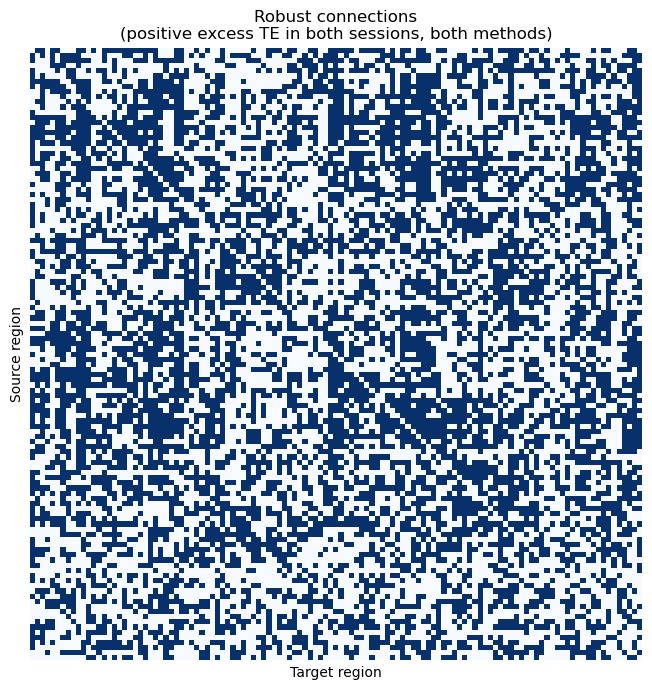

In [99]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
sns.heatmap(
    robust_mask.astype(int),
    ax=ax,
    cmap="Blues",
    square=True,
    cbar=False,
    xticklabels=False,
    yticklabels=False
)
ax.set_title("Robust connections\n(positive excess TE in both sessions, both methods)")
ax.set_xlabel("Target region")
ax.set_ylabel("Source region")
plt.tight_layout()
plt.show()

Averaging also across both (Gauss and Copula) methods

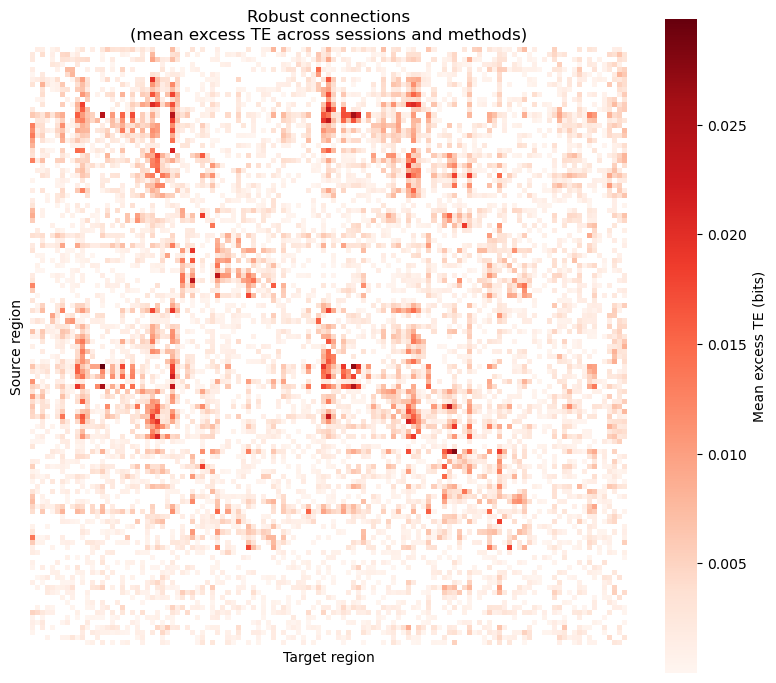

In [100]:
# Average excess TE across sessions for each method
avg_gauss  = (TE_excess_gauss_1  + TE_excess_gauss_2)  / 2
avg_copula = (TE_excess_copula_1 + TE_excess_copula_2) / 2

# Average across methods too
avg_both = (avg_gauss + avg_copula) / 2

# Apply robust mask — set non-robust connections to NaN so they appear blank
avg_robust = np.where(robust_mask, avg_both, np.nan)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
sns.heatmap(
    avg_robust,
    ax=ax,
    cmap="Reds",
    square=True,
    cbar_kws={"label": "Mean excess TE (bits)"},
    xticklabels=False,
    yticklabels=False
)
ax.set_title("Robust connections\n(mean excess TE across sessions and methods)")
ax.set_xlabel("Target region")
ax.set_ylabel("Source region")
plt.tight_layout()
plt.show()

Here we can filter also the other two methods to keep only pairs that are in Gauss and Copula and check which remain in all methods separately (averaging across datasets). 

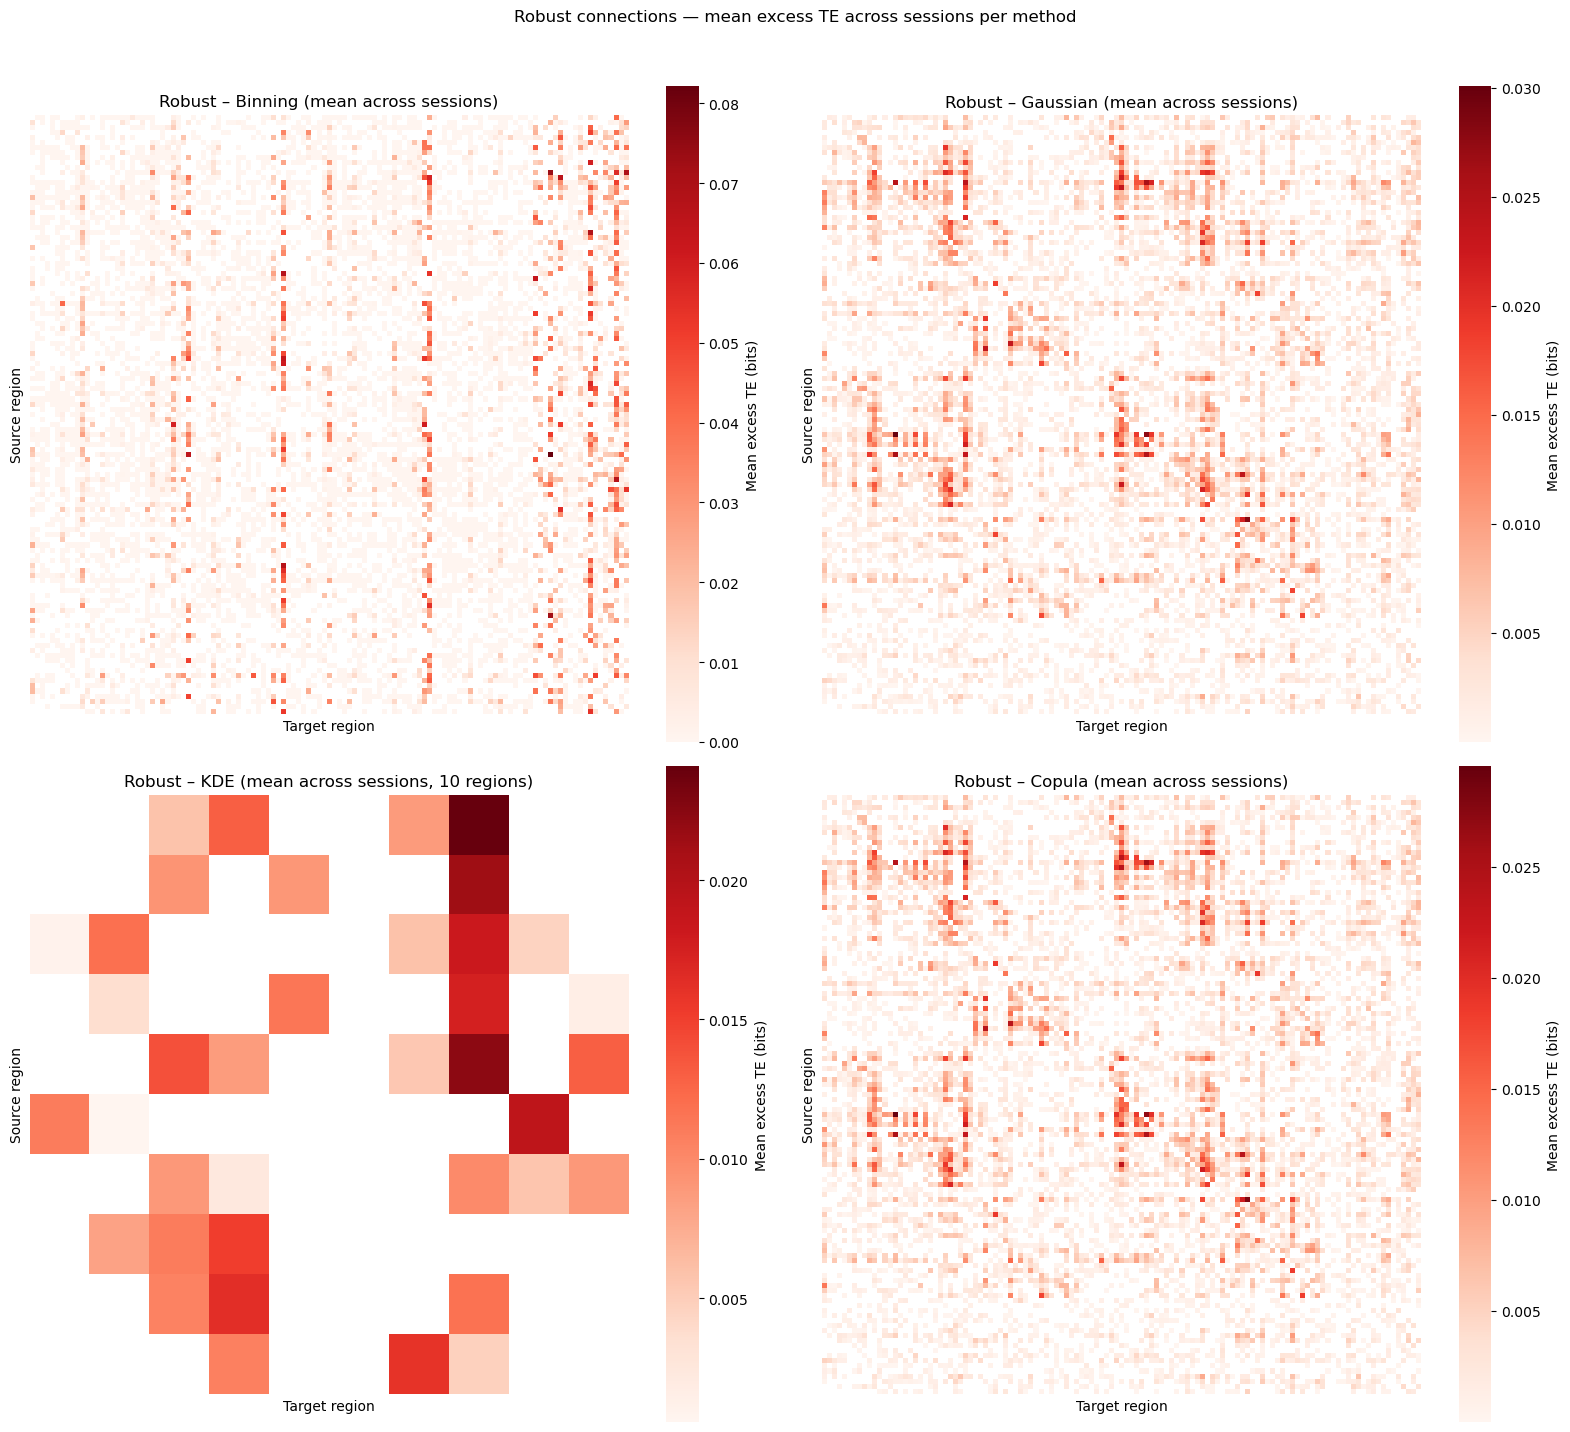

In [101]:
# Mean across sessions for each method
avg_gauss  = (TE_excess_gauss_1  + TE_excess_gauss_2)  / 2
avg_copula = (TE_excess_copula_1 + TE_excess_copula_2) / 2
avg_bin    = (TE_excess_bin_1    + TE_excess_bin_2)    / 2

# For KDE: robust_mask is 119x119 but KDE is 10x10
# So we need a separate robust mask for KDE

mask_kde_1 = TE_excess_kde_1 > 0
mask_kde_2 = TE_excess_kde_2 > 0
robust_mask_kde = mask_kde_1 & mask_kde_2
np.fill_diagonal(robust_mask_kde, False)
avg_kde = (TE_excess_kde_1 + TE_excess_kde_2) / 2

# Apply robust mask to each method
avg_gauss_robust  = np.where(robust_mask,     avg_gauss,  np.nan)
avg_copula_robust = np.where(robust_mask,     avg_copula, np.nan)
avg_bin_robust    = np.where(robust_mask,     avg_bin,    np.nan)
avg_kde_robust    = np.where(robust_mask_kde, avg_kde,    np.nan)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
matrices = [avg_bin_robust, avg_gauss_robust, avg_kde_robust, avg_copula_robust]
titles   = ["Robust – Binning (mean across sessions)",
"Robust – Gaussian (mean across sessions)",
"Robust – KDE (mean across sessions, 10 regions)",
"Robust – Copula (mean across sessions)"]
for ax, mat, title in zip(axes.flat, matrices, titles):
    sns.heatmap(
        mat,
        ax=ax,
        cmap="Reds",
        square=True,
        cbar_kws={"label": "Mean excess TE (bits)"},
        xticklabels=False,
        yticklabels=False
    )
    ax.set_title(title)
    ax.set_xlabel("Target region")
    ax.set_ylabel("Source region")
plt.suptitle("Robust connections — mean excess TE across sessions per method", y=1.02)
plt.tight_layout()
plt.show()

**OR** we could also look for surviving excess TE across ALL 4 methods... but it does not make much sense since KDE and binning are not really reliable... they depend on many assumptions and do very differently from Gauss and Copula...

/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


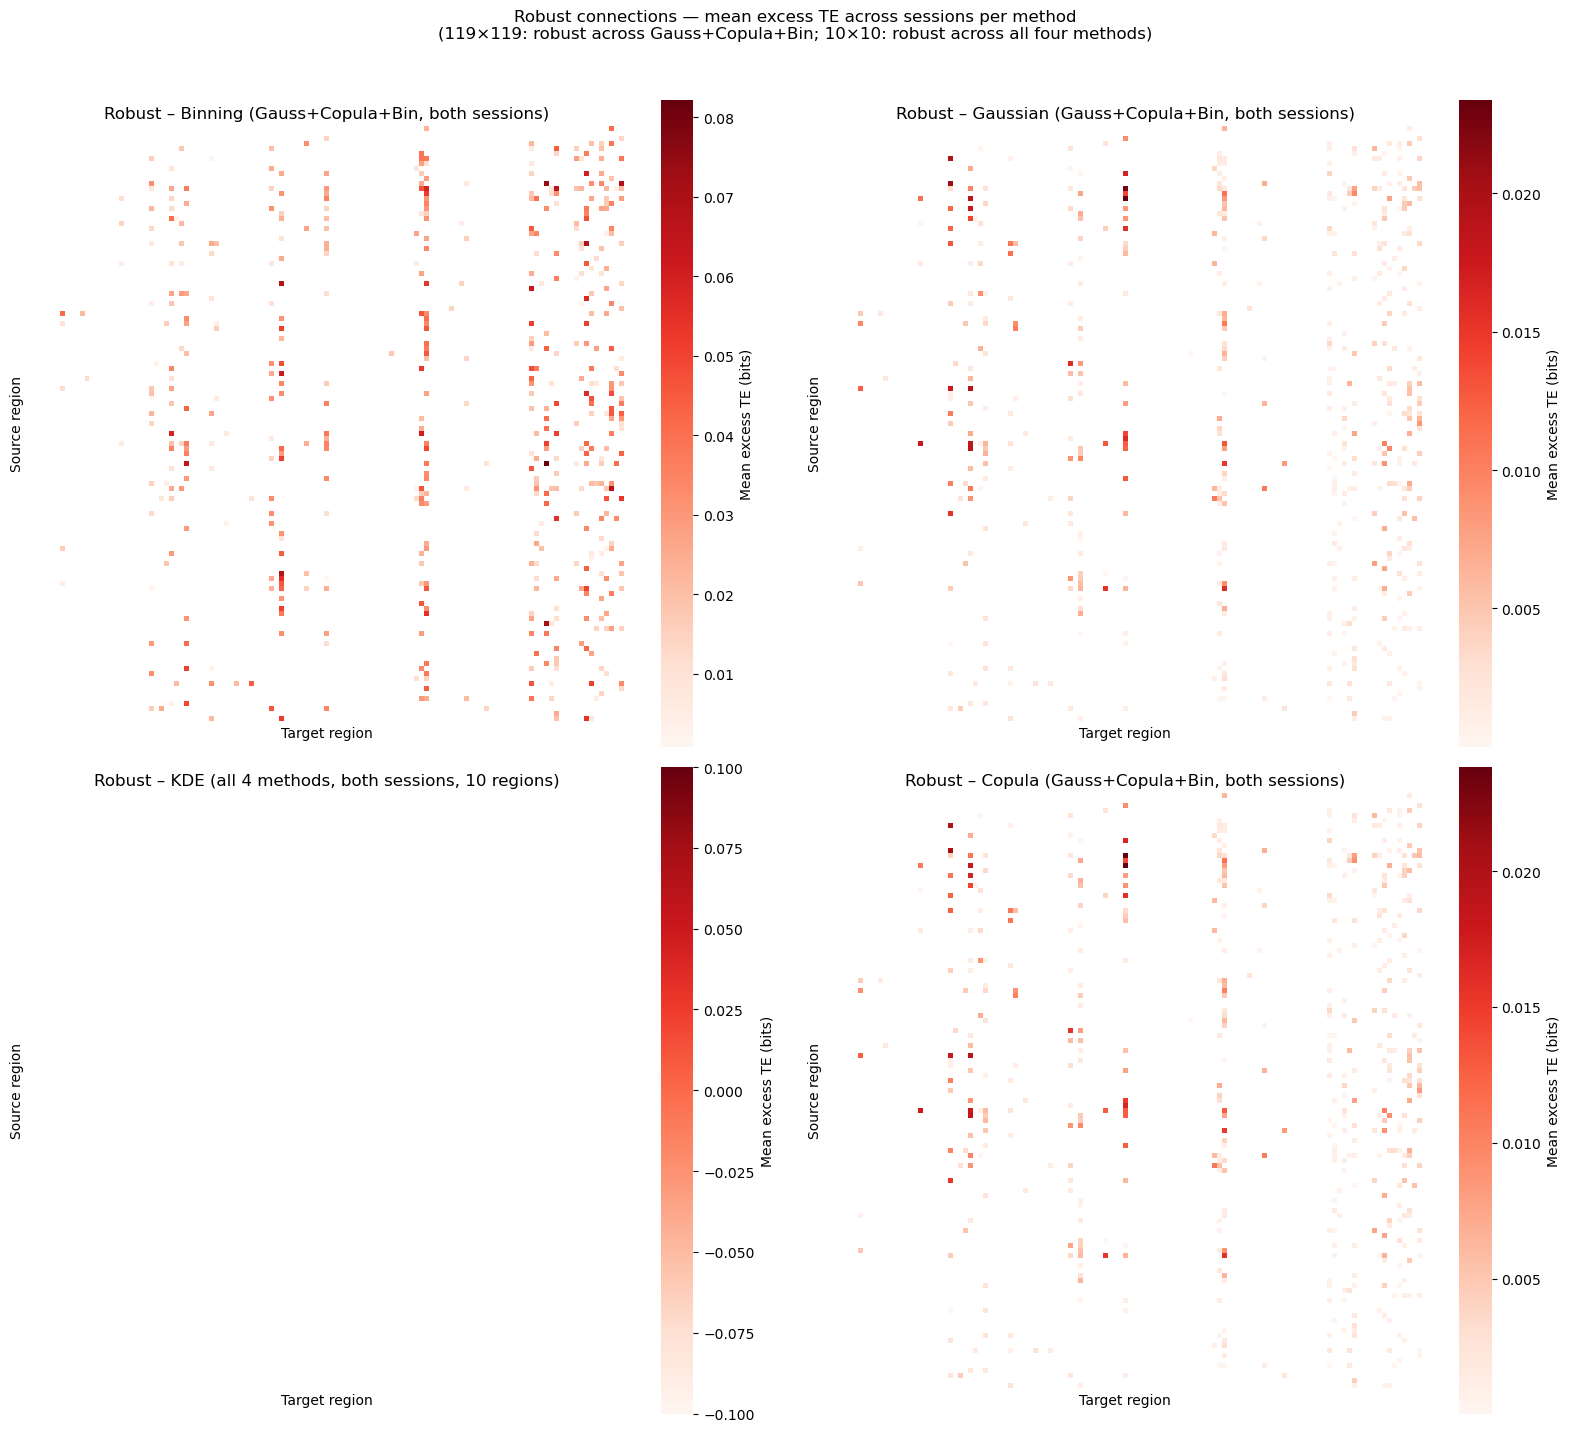

In [102]:
#  Full 119x119 robust mask (Gauss + Copula + Binning, both sessions) 
robust_mask_full = (
    (TE_excess_gauss_1  > 0) & (TE_excess_gauss_2  > 0) &
    (TE_excess_copula_1 > 0) & (TE_excess_copula_2 > 0) &
    (TE_excess_bin_1    > 0) & (TE_excess_bin_2    > 0)
)
np.fill_diagonal(robust_mask_full, False)

# 10x10 robust mask (all four methods, both sessions) 
robust_mask_10 = (
    (TE_excess_gauss_1[:10,:10]  > 0) & (TE_excess_gauss_2[:10,:10]  > 0) &
    (TE_excess_copula_1[:10,:10] > 0) & (TE_excess_copula_2[:10,:10] > 0) &
    (TE_excess_bin_1[:10,:10]    > 0) & (TE_excess_bin_2[:10,:10]    > 0) &
    (TE_excess_kde_1             > 0) & (TE_excess_kde_2             > 0)
)
np.fill_diagonal(robust_mask_10, False)

# Mean across sessions for each method 
avg_gauss  = (TE_excess_gauss_1  + TE_excess_gauss_2)  / 2
avg_copula = (TE_excess_copula_1 + TE_excess_copula_2) / 2
avg_bin    = (TE_excess_bin_1    + TE_excess_bin_2)    / 2
avg_kde    = (TE_excess_kde_1    + TE_excess_kde_2)    / 2

# Apply masks 
avg_gauss_robust  = np.where(robust_mask_full, avg_gauss,  np.nan)
avg_copula_robust = np.where(robust_mask_full, avg_copula, np.nan)
avg_bin_robust    = np.where(robust_mask_full, avg_bin,    np.nan)
avg_kde_robust    = np.where(robust_mask_10,   avg_kde,    np.nan)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

matrices = [avg_bin_robust, avg_gauss_robust, avg_kde_robust, avg_copula_robust]
titles   = [
    "Robust – Binning (Gauss+Copula+Bin, both sessions)",
    "Robust – Gaussian (Gauss+Copula+Bin, both sessions)",
    "Robust – KDE (all 4 methods, both sessions, 10 regions)",
    "Robust – Copula (Gauss+Copula+Bin, both sessions)"
]

for ax, mat, title in zip(axes.flat, matrices, titles):
    sns.heatmap(
        mat,
        ax=ax,
        cmap="Reds",
        square=True,
        cbar_kws={"label": "Mean excess TE (bits)"},
        xticklabels=False,
        yticklabels=False
    )
    ax.set_title(title)
    ax.set_xlabel("Target region")
    ax.set_ylabel("Source region")

plt.suptitle("Robust connections — mean excess TE across sessions per method\n"
             "(119×119: robust across Gauss+Copula+Bin; "
             "10×10: robust across all four methods)",
             y=1.02)
plt.tight_layout()
plt.show()

Can we conclude that these are genuine connections?

# **ABOUT THE LAG**

Let's see what happens to the final analysis if we change the lag (starting from 1 since if X and Y are simultaneous you cannot say which caused which). 

Computing lag 2...
Computing lag 5...
Computing lag 10...
Computing lag 20...


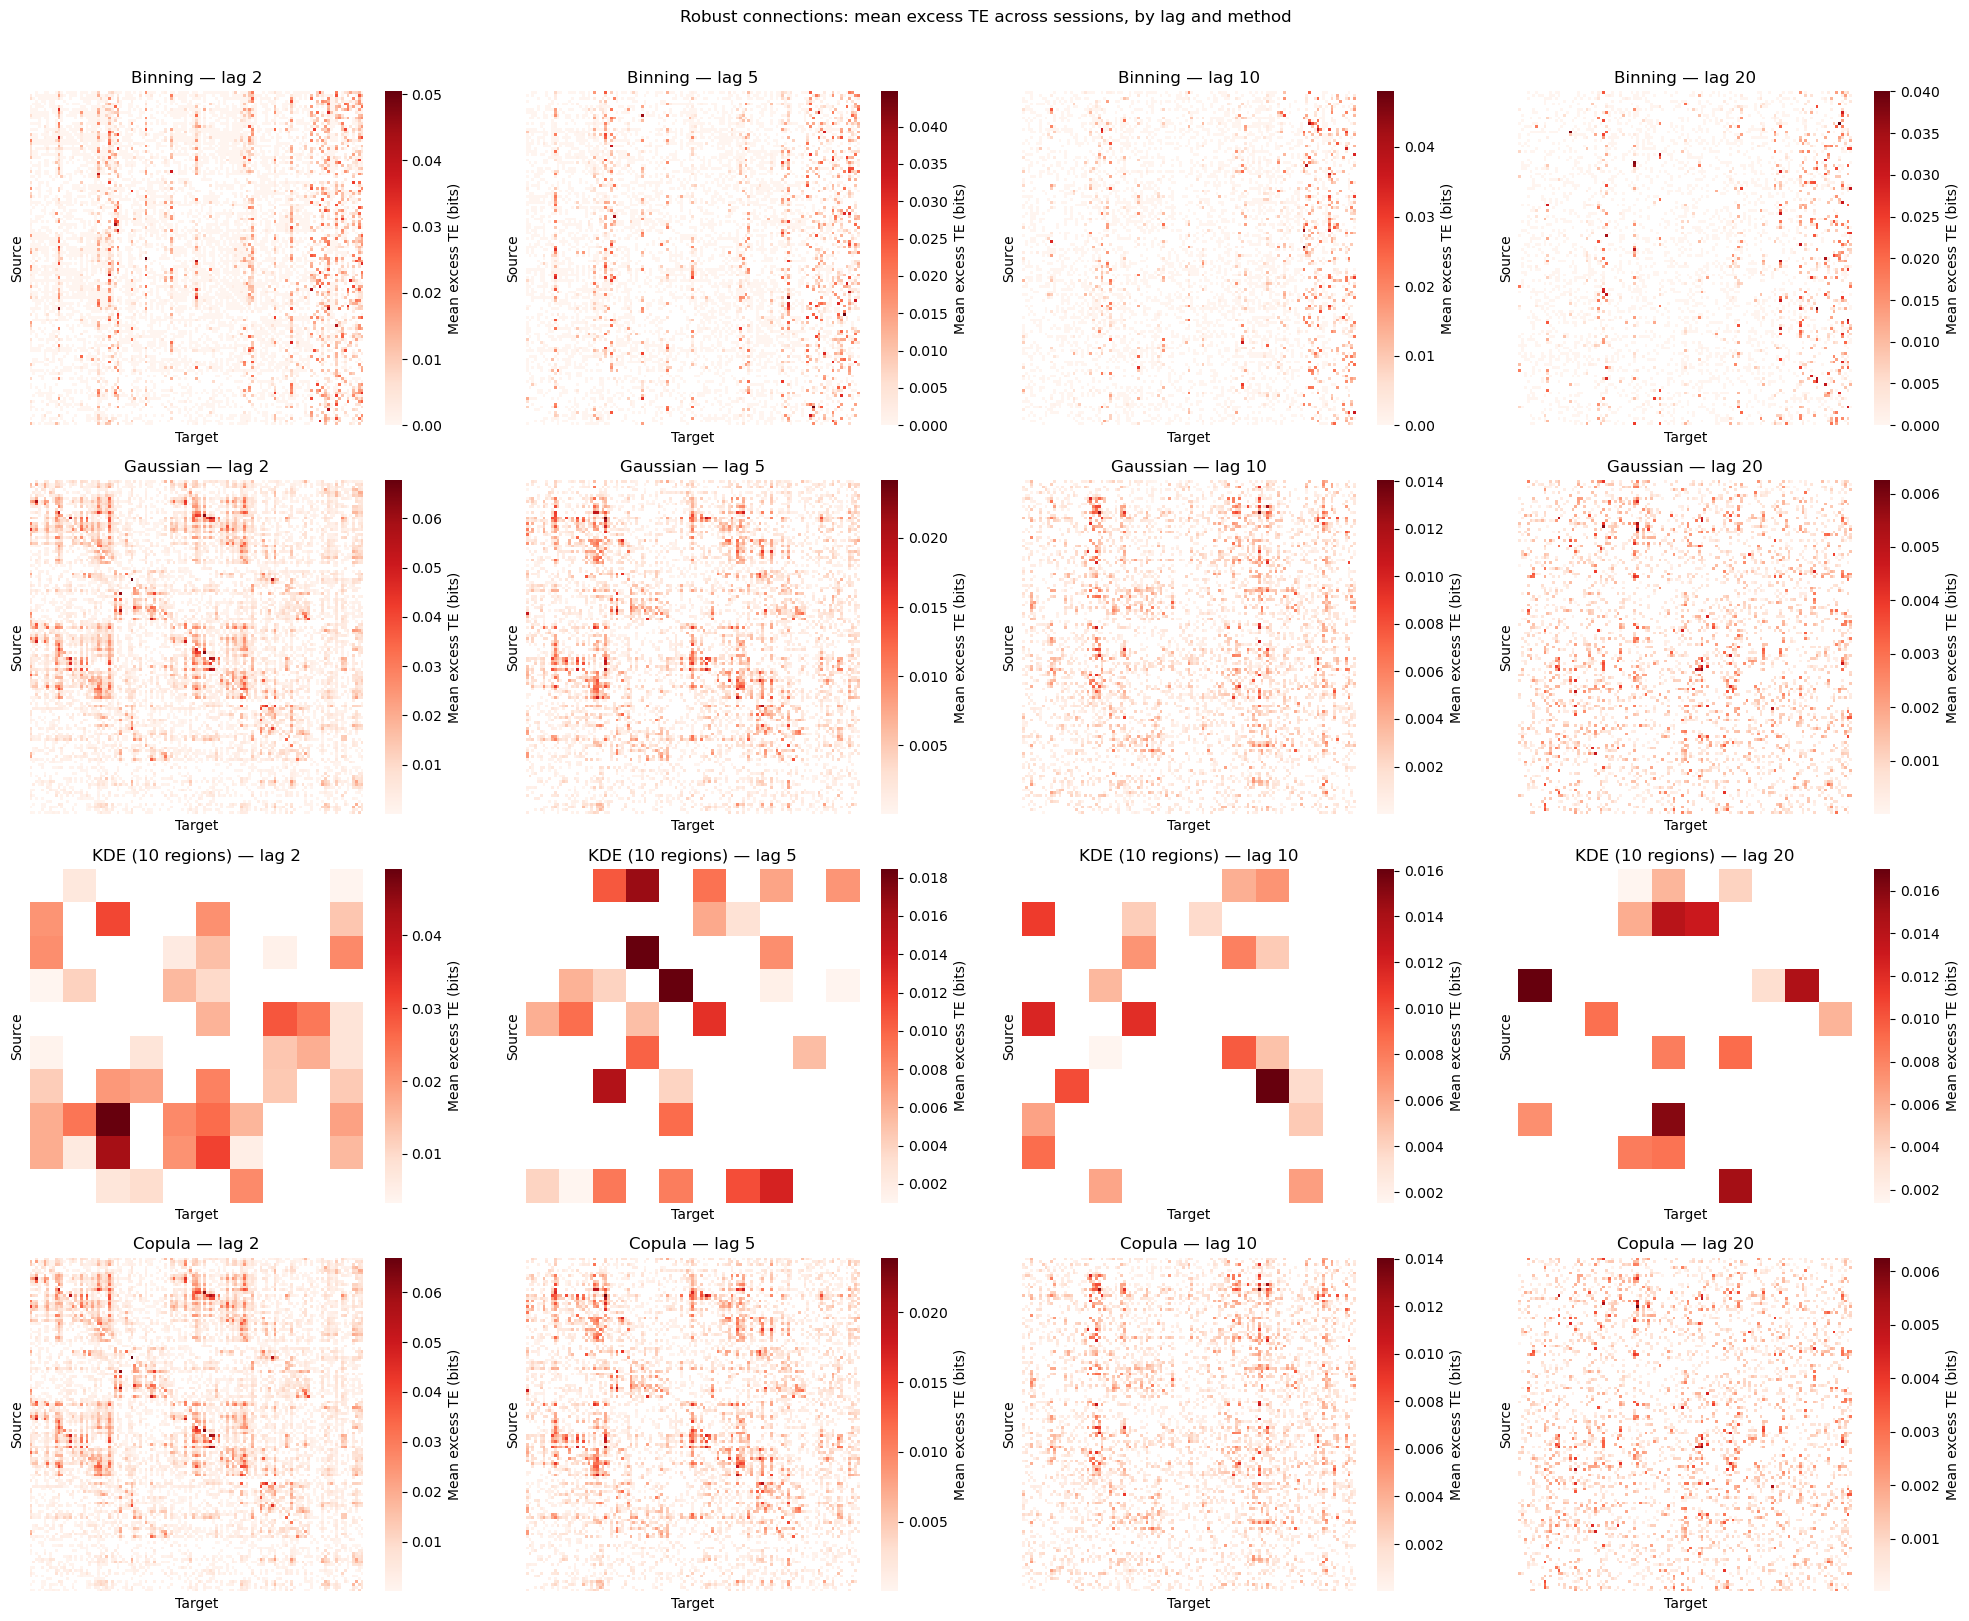

In [103]:
lags = [2, 5, 10, 20]
results = {}

for lag in lags:
    print(f"Computing lag {lag}...")

    # --- Real TE matrices (ALL four methods) ---
    te_g1 = nlib.transfer_entropy_matrix(data1_mat,       method="gaussian", lag=lag)
    te_g2 = nlib.transfer_entropy_matrix(data2_mat,       method="gaussian", lag=lag)
    te_c1 = nlib.transfer_entropy_matrix(data1_mat,       method="copula",   lag=lag)
    te_c2 = nlib.transfer_entropy_matrix(data2_mat,       method="copula",   lag=lag)
    te_b1 = nlib.transfer_entropy_matrix(data1_mat,       method="binning",  lag=lag, n_bins=nbins)
    te_b2 = nlib.transfer_entropy_matrix(data2_mat,       method="binning",  lag=lag, n_bins=nbins)
    te_k1 = nlib.transfer_entropy_matrix(data1_mat[:10],  method="kde",      lag=lag)
    te_k2 = nlib.transfer_entropy_matrix(data2_mat[:10],  method="kde",      lag=lag)

    # --- Null matrices (fresh shuffle each lag) ---
    shuf1 = np.array([np.random.permutation(data1_mat[i]) for i in range(data1_mat.shape[0])])
    shuf2 = np.array([np.random.permutation(data2_mat[i]) for i in range(data2_mat.shape[0])])

    null_g1 = nlib.transfer_entropy_matrix(shuf1,       method="gaussian", lag=lag)
    null_g2 = nlib.transfer_entropy_matrix(shuf2,       method="gaussian", lag=lag)
    null_c1 = nlib.transfer_entropy_matrix(shuf1,       method="copula",   lag=lag)
    null_c2 = nlib.transfer_entropy_matrix(shuf2,       method="copula",   lag=lag)
    null_b1 = nlib.transfer_entropy_matrix(shuf1,       method="binning",  lag=lag, n_bins=nbins)
    null_b2 = nlib.transfer_entropy_matrix(shuf2,       method="binning",  lag=lag, n_bins=nbins)
    null_k1 = nlib.transfer_entropy_matrix(shuf1[:10],  method="kde",      lag=lag)
    null_k2 = nlib.transfer_entropy_matrix(shuf2[:10],  method="kde",      lag=lag)

    # --- Excess TE (clipped at zero) ---
    exc_g1 = np.maximum(te_g1 - null_g1, 0)
    exc_g2 = np.maximum(te_g2 - null_g2, 0)
    exc_c1 = np.maximum(te_c1 - null_c1, 0)
    exc_c2 = np.maximum(te_c2 - null_c2, 0)
    exc_b1 = np.maximum(te_b1 - null_b1, 0)
    exc_b2 = np.maximum(te_b2 - null_b2, 0)
    exc_k1 = np.maximum(te_k1 - null_k1, 0)
    exc_k2 = np.maximum(te_k2 - null_k2, 0)

    # --- Robust mask: positive in both sessions, Gauss + Copula ---
    robust = (
        (exc_g1 > 0) & (exc_g2 > 0) &
        (exc_c1 > 0) & (exc_c2 > 0)
    )
    np.fill_diagonal(robust, False)

    robust_kde = (exc_k1 > 0) & (exc_k2 > 0)
    np.fill_diagonal(robust_kde, False)

    # --- Mean across sessions, masked ---
    results[lag] = {
        'gauss':  np.where(robust,     (exc_g1 + exc_g2) / 2, np.nan),
        'copula': np.where(robust,     (exc_c1 + exc_c2) / 2, np.nan),
        'bin':    np.where(robust,     (exc_b1 + exc_b2) / 2, np.nan),
        'kde':    np.where(robust_kde, (exc_k1 + exc_k2) / 2, np.nan),
    }

# --- Plot ---
methods       = ['bin',     'gauss',    'kde',              'copula']
method_labels = ['Binning', 'Gaussian', 'KDE (10 regions)', 'Copula']

fig, axes = plt.subplots(len(methods), len(lags),
                         figsize=(5 * len(lags), 4 * len(methods)))

for row, (mth, label) in enumerate(zip(methods, method_labels)):
    for col, lag in enumerate(lags):
        ax  = axes[row, col]
        mat = results[lag][mth]
        sns.heatmap(
            mat,
            ax=ax,
            cmap="Reds",
            square=True,
            cbar=True,
            cbar_kws={"label": "Mean excess TE (bits)"},
            xticklabels=False,
            yticklabels=False
        )
        ax.set_title(f"{label} — lag {lag}")
        ax.set_xlabel("Target")
        ax.set_ylabel("Source")

plt.suptitle("Robust connections: mean excess TE across sessions, by lag and method", y=1.01)
plt.tight_layout()
plt.show()

We can see, 

**Gaussian & copula**: number of visible robust connections clearly decreases from lag 2 to lag 20. he upper-left block that was prominent at lag 1 becomes progressively sparser. This is exactly the expected behavior — as lag increases, $X_{t - l}$ carries less and less information about $Y_t$ beyond what $Y_{t-1}$ already explains, because the signal decorrelates over time. 

**KDE**: The scale does decrease with lag, and fewer connections survive the robust mask at higher lags. However as we established, the block structure in KDE is dominated by estimation artifacts, so this decay could reflect either real signal decay or artifact decay. Not conclusive on its own.

**Binning:** This is the most concerning panel. The colorbar shows negative values at all lags, which should not happen for a mean excess TE — negative excess means the real TE was below the null for those pairs. This confirms that even after null subtraction, the structured bias in binning is so large and variable that the subtraction introduces negative artifacts. The stripe structure persists at all lags with no clear decay trend. Discard binning from the lag analysis conclusions.

Overall, lag leads to gradual disappearance of robust connections, and this is clearly supported by Gaussian and Copula. 

# **CONSIDERING ONLY 10 REGIONS for all methods**

Computing lag 1...
Computing lag 2...
Computing lag 5...
Computing lag 10...
Computing lag 20...


/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/giorgiafasiolo/opt/anaconda3/envs/qh_env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountere

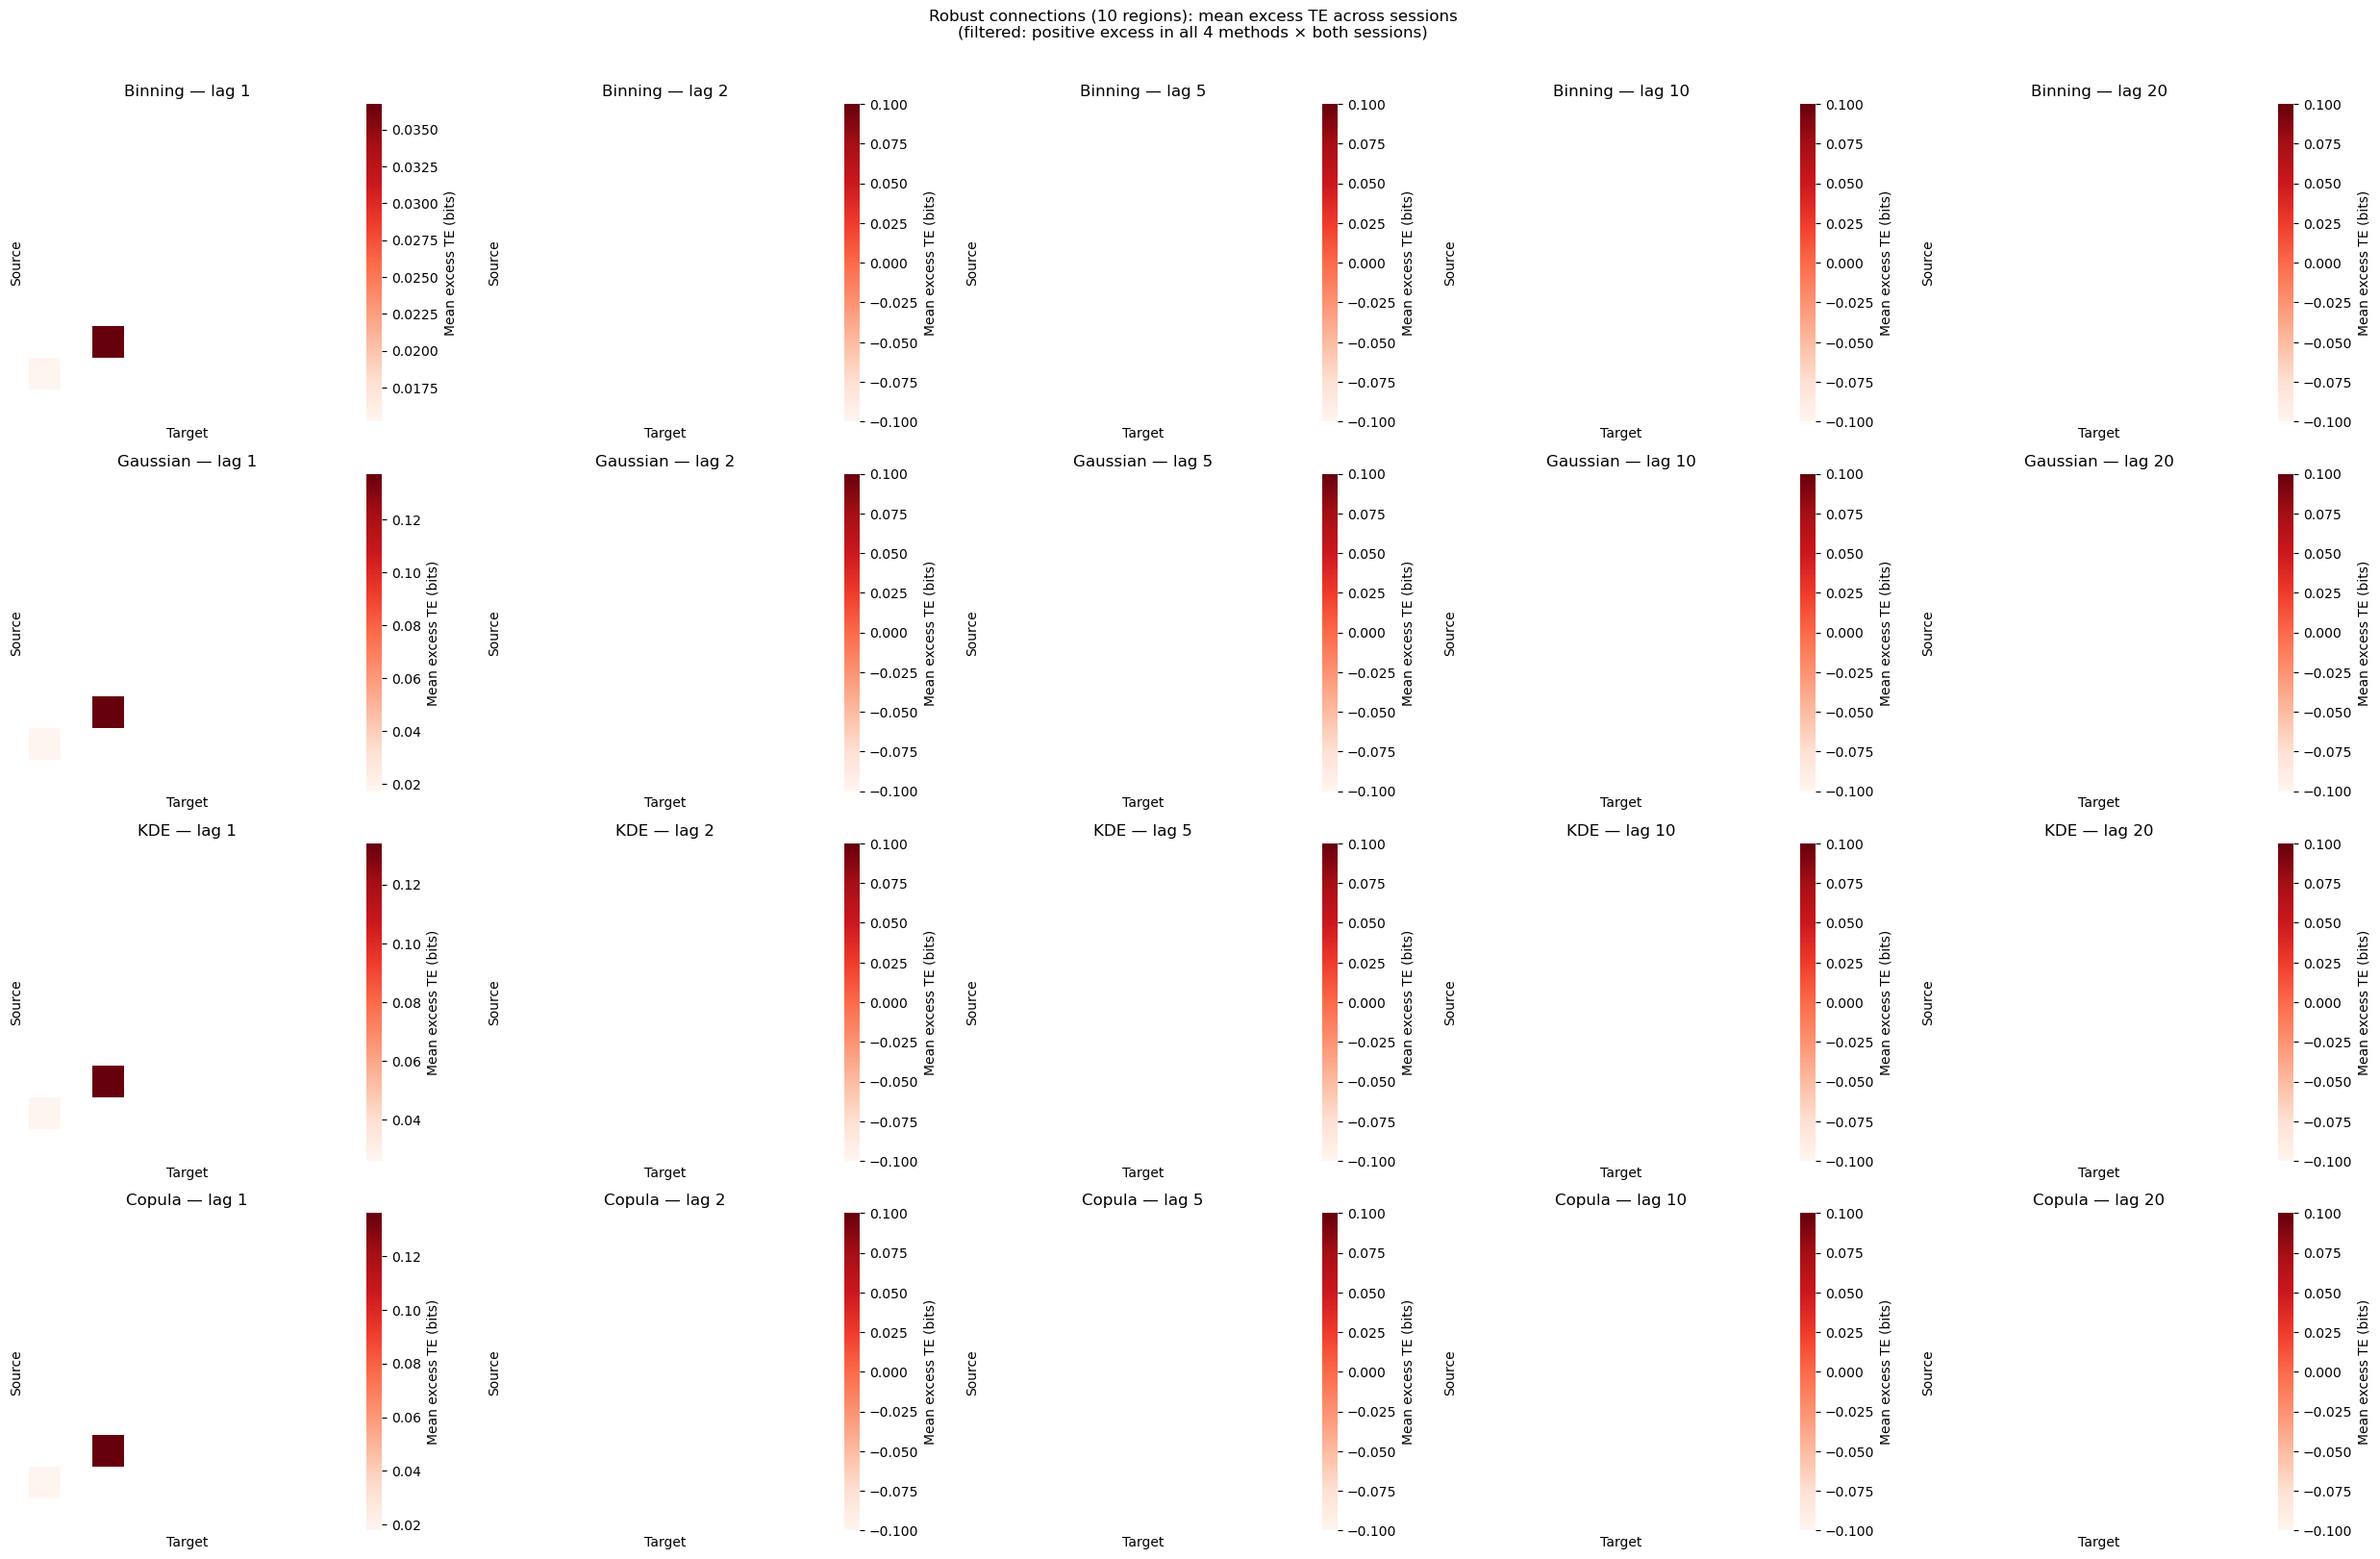

In [104]:
# ============================================================
# PARAMETERS — change these to explore different settings
# ============================================================
N_REGIONS  = 10          # number of regions to analyse (upper-left submatrix)
LAGS       = [1, 2, 5, 10, 20]  # lags to sweep over
N_BINS     = int(1200**(1/3))   # number of bins for binning estimator
ALPHA_KDE  = 1.0         # KDE bandwidth scaling factor
# ============================================================

results = {}

for lag in LAGS:
    print(f"Computing lag {lag}...")

    # Submatrices restricted to N_REGIONS
    d1 = data1_mat[:N_REGIONS, :]
    d2 = data2_mat[:N_REGIONS, :]

    # --- Real TE matrices ---
    te_g1 = nlib.transfer_entropy_matrix(d1, method="gaussian", lag=lag)
    te_g2 = nlib.transfer_entropy_matrix(d2, method="gaussian", lag=lag)
    te_c1 = nlib.transfer_entropy_matrix(d1, method="copula",   lag=lag)
    te_c2 = nlib.transfer_entropy_matrix(d2, method="copula",   lag=lag)
    te_b1 = nlib.transfer_entropy_matrix(d1, method="binning",  lag=lag, n_bins=N_BINS)
    te_b2 = nlib.transfer_entropy_matrix(d2, method="binning",  lag=lag, n_bins=N_BINS)
    te_k1 = nlib.transfer_entropy_matrix(d1, method="kde",      lag=lag, alpha=ALPHA_KDE)
    te_k2 = nlib.transfer_entropy_matrix(d2, method="kde",      lag=lag, alpha=ALPHA_KDE)

    # --- Null matrices (fresh shuffle each lag) ---
    shuf1 = np.array([np.random.permutation(d1[i]) for i in range(N_REGIONS)])
    shuf2 = np.array([np.random.permutation(d2[i]) for i in range(N_REGIONS)])

    null_g1 = nlib.transfer_entropy_matrix(shuf1, method="gaussian", lag=lag)
    null_g2 = nlib.transfer_entropy_matrix(shuf2, method="gaussian", lag=lag)
    null_c1 = nlib.transfer_entropy_matrix(shuf1, method="copula",   lag=lag)
    null_c2 = nlib.transfer_entropy_matrix(shuf2, method="copula",   lag=lag)
    null_b1 = nlib.transfer_entropy_matrix(shuf1, method="binning",  lag=lag, n_bins=N_BINS)
    null_b2 = nlib.transfer_entropy_matrix(shuf2, method="binning",  lag=lag, n_bins=N_BINS)
    null_k1 = nlib.transfer_entropy_matrix(shuf1, method="kde",      lag=lag, alpha=ALPHA_KDE)
    null_k2 = nlib.transfer_entropy_matrix(shuf2, method="kde",      lag=lag, alpha=ALPHA_KDE)

    # --- Excess TE (clipped at zero) ---
    exc_g1 = np.maximum(te_g1 - null_g1, 0)
    exc_g2 = np.maximum(te_g2 - null_g2, 0)
    exc_c1 = np.maximum(te_c1 - null_c1, 0)
    exc_c2 = np.maximum(te_c2 - null_c2, 0)
    exc_b1 = np.maximum(te_b1 - null_b1, 0)
    exc_b2 = np.maximum(te_b2 - null_b2, 0)
    exc_k1 = np.maximum(te_k1 - null_k1, 0)
    exc_k2 = np.maximum(te_k2 - null_k2, 0)

    # --- Robust mask: positive in ALL four methods AND both sessions ---
    robust = (
        (exc_g1 > 0) & (exc_g2 > 0) &
        (exc_c1 > 0) & (exc_c2 > 0) &
        (exc_b1 > 0) & (exc_b2 > 0) &
        (exc_k1 > 0) & (exc_k2 > 0)
    )
    np.fill_diagonal(robust, False)

    # --- Mean across sessions per method, masked ---
    results[lag] = {
        'gauss':  np.where(robust, (exc_g1 + exc_g2) / 2, np.nan),
        'copula': np.where(robust, (exc_c1 + exc_c2) / 2, np.nan),
        'bin':    np.where(robust, (exc_b1 + exc_b2) / 2, np.nan),
        'kde':    np.where(robust, (exc_k1 + exc_k2) / 2, np.nan),
    }

# --- Plot: one row per method, one column per lag ---
methods       = ['bin',      'gauss',    'kde', 'copula']
method_labels = ['Binning',  'Gaussian', 'KDE', 'Copula']

fig, axes = plt.subplots(len(methods), len(LAGS),
                         figsize=(5 * len(LAGS), 4 * len(methods)))

for row, (mth, label) in enumerate(zip(methods, method_labels)):
    for col, lag in enumerate(LAGS):
        ax  = axes[row, col]
        mat = results[lag][mth]
        sns.heatmap(
            mat,
            ax=ax,
            cmap="Reds",
            square=True,
            cbar=True,
            cbar_kws={"label": "Mean excess TE (bits)"},
            xticklabels=False,
            yticklabels=False
        )
        ax.set_title(f"{label} — lag {lag}")
        ax.set_xlabel("Target")
        ax.set_ylabel("Source")

plt.suptitle(
    f"Robust connections ({N_REGIONS} regions): mean excess TE across sessions\n"
    f"(filtered: positive excess in all 4 methods × both sessions)",
    y=1.01
)
plt.tight_layout()
plt.show()